In [1]:
# import pywavefront

# from pywavefront.mesh import Mesh

# from pywavefront import visualization

# # Load the OBJ file
# scene = pywavefront.Wavefront('/home/seungwoo/alchemist_ws/src/BPMP-Tracker/script/AllStaticMesh.OBJ')


# # Access data like vertices, faces, etc.
# # For example, to access the first mesh's vertices:


# # visualize
# visualization.draw(scene)



from typing import List, Tuple, Optional
import numpy as np
from tqdm import tqdm

def _fix_idx(idx: int, n: int) -> int:
    """OBJ 인덱스 보정: 1-based, 음수는 뒤에서부터."""
    return idx-1 if idx > 0 else n + idx

def load_obj(path: str):
    V: List[Tuple[float,float,float]] = []
    VT: List[Tuple[float,...]] = []
    VN: List[Tuple[float,float,float]] = []
    Fv: List[Tuple[int,int,int]] = []
    Fvt: List[Tuple[int,int,int]] = []
    Fvn: List[Tuple[int,int,int]] = []

    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in tqdm(f, desc="Loading OBJ file"):
            if not line or line.startswith('#'): 
                continue
            parts = line.strip().split()
            if not parts:
                continue
            tag, vals = parts[0], parts[1:]

            if tag == 'v':
                V.append(tuple(map(float, vals[:3])))
            elif tag == 'vt':
                # u v [w] 지원
                UVW = tuple(map(float, vals[:3]))
                VT.append(UVW)
            elif tag == 'vn':
                VN.append(tuple(map(float, vals[:3])))
            elif tag == 'f':
                # 다각형 지원 -> 삼각 팬 분할
                # 각 토큰은 i, i/j, i//k, i/j/k 형태
                verts = []
                texs  = []
                norms = []
                for tok in vals:
                    a = tok.split('/')
                    vi = int(a[0]) if a[0] else 0
                    ti = int(a[1]) if len(a) > 1 and a[1] else 0
                    ni = int(a[2]) if len(a) > 2 and a[2] else 0
                    verts.append(_fix_idx(vi, len(V)))
                    texs.append(_fix_idx(ti, len(VT)) if ti else None)
                    norms.append(_fix_idx(ni, len(VN)) if ni else None)

                # 팬 삼각화: (0, k-1, k)
                for k in range(2, len(verts)):
                    Fv.append((verts[0], verts[k-1], verts[k]))
                    if any(t is not None for t in texs):
                        Fvt.append((texs[0], texs[k-1], texs[k]))
                    if any(n is not None for n in norms):
                        Fvn.append((norms[0], norms[k-1], norms[k]))

    V  = np.asarray(V, dtype=np.float32) if V else np.zeros((0,3), np.float32)
    VT = np.asarray(VT, dtype=np.float32) if VT else np.zeros((0,2), np.float32)
    VN = np.asarray(VN, dtype=np.float32) if VN else np.zeros((0,3), np.float32)
    Fv = np.asarray(Fv, dtype=np.int32) if Fv else np.zeros((0,3), np.int32)
    Fvt = np.asarray(Fvt, dtype=object) if Fvt else None
    Fvn = np.asarray(Fvn, dtype=object) if Fvn else None

    # vt가 3D로 온 경우(uvw) → uv만 사용 원하면 아래 주석 해제
    # if VT.shape[1] == 3:
    #     VT = VT[:, :2]

    return V, VT, VN, Fv, Fvt, Fvn


# if __name__ == '__main__':
import pickle
obj_path = '/home/seungwoo/alchemist_ws/src/BPMP-Tracker/script/AllStaticMesh.OBJ'
V, VT, VN, Fv, Fvt, Fvn = load_obj(obj_path)

# visualize using trimesh
# import trimesh
# mesh = trimesh.Trimesh(vertices=V, faces=Fv, vertex_normals=VN if len(VN) == len(V) else None)
# mesh.show()

import numpy as np
import open3d as o3d
from PIL import Image
import matplotlib.pyplot as plt

# V, VT, Fv, Fvt 는 이미 당신 파서 결과라고 가정
# 1) Mesh 구성
mesh_origin = o3d.geometry.TriangleMesh(
    vertices=o3d.utility.Vector3dVector(V.astype(float)),
    triangles=o3d.utility.Vector3iVector(Fv.astype(int))
)
# transform the mesh to align with the coordinate system if needed
mesh_origin.transform([[0, 0, 1, 0],
                [1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 0, 1]])



Loading OBJ file: 6517259it [00:05, 1088394.29it/s]


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


TriangleMesh with 2793105 points and 931035 triangles.

In [2]:
coord = o3d.geometry.TriangleMesh.create_coordinate_frame(size=50.0, origin=[0, 0, 0])

o3d.visualization.draw_geometries([mesh_origin,coord])


In [3]:
import copy
mesh = copy.deepcopy(mesh_origin)    
# mesh에서 특정 높이만큼 자르기
z_min, z_max = 0, 300
x_min, x_max = -1100, 1800
y_min, y_max = -1200, 750
bbox = o3d.geometry.AxisAlignedBoundingBox(min_bound=(x_min, y_min, z_min), max_bound=(x_max, y_max, z_max))
mesh = mesh.crop(bbox)

# mesh 에 높이에 따른 색 입히기
z_values = np.asarray(mesh.vertices)[:, 2]
z_norm = (z_values - z_min) / (z_max - z_min + 1e-8)  # 0~1 정규화
# colors = plt.cm.viridis(z_norm)[:, :3]  # viridis 컬러맵에서 RGB 추출
colors = plt.cm.get_cmap('jet')(z_norm)[:, :3]  # jet 컬러맵에서 RGB 추출
mesh.vertex_colors = o3d.utility.Vector3dVector(colors)


x_offset = 717.464 - (-215.0)
y_offset = -287.73 - 68.4938

mesh = mesh.translate((x_offset, y_offset, 0))
mesh = mesh.rotate(o3d.geometry.get_rotation_matrix_from_xyz((0, 0, -np.deg2rad(90))), center=(0,0,0))

o3d.visualization.draw_geometries([mesh,coord])

## load rosbag

In [4]:
# -*- coding: utf-8 -*-
# ===============================================================
# rosbag 스냅샷 + TF 정규화 + 경로 누적 플롯 (feasible/raw/best, corridors, robot/target/dynamics)
# - 동적장애물: /bpmp_simulator/obstacle_state_list (ObjectStateList)
# - feasible/raw/best: visualization_msgs/MarkerArray (1번 코드 정렬 로직 유지)
# - corridors: decomp_ros_msgs/PolyhedronArray (2번 코드 모양 정확도 유지: H-rep half-plane clipping)
# ===============================================================

from collections import defaultdict
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle



# -------------------- 유틸 --------------------
def pick_closest(msg_list: List[Tuple[float, object]], t_query: float):
    if not msg_list: return None
    idx = int(np.argmin([abs(t - t_query) for t, _ in msg_list]))
    return msg_list[idx]

def pose_xyz_from_any(msg):
    if hasattr(msg, "pose") and hasattr(msg.pose, "pose") and hasattr(msg.pose.pose, "position"):
        p = msg.pose.pose.position
        return np.array([float(p.x), float(p.y), float(p.z)], dtype=float), getattr(msg, 'header', None)
    if hasattr(msg, "pose") and hasattr(msg.pose, "position"):
        p = msg.pose.position
        return np.array([float(p.x), float(p.y), float(p.z)], dtype=float), getattr(msg, 'header', None)
    if hasattr(msg, "px") and hasattr(msg, "py") and hasattr(msg, "pz"):
        return np.array([float(msg.px), float(msg.py), float(msg.pz)], dtype=float), None
    return None, None

def hull2d_monotone_chain(points_xy: np.ndarray):
    pts = np.unique(points_xy, axis=0)
    if len(pts) <= 1: return pts
    pts = pts[pts[:,0].argsort(kind='mergesort')]
    def cross(o, a, b): return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0: lower.pop()
        lower.append(tuple(p))
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0: upper.pop()
        upper.append(tuple(p))
    return np.array(lower[:-1] + upper[:-1], dtype=float)

def quat_to_R(x,y,z,w):
    xx, yy, zz = x*x, y*y, z*z; xy, xz, yz = x*y, x*z, y*z; wx, wy, wz = w*x, w*y, w*z
    return np.array([[1-2*(yy+zz), 2*(xy-wz),   2*(xz+wy)],
                     [2*(xy+wz),   1-2*(xx+zz), 2*(yz-wx)],
                     [2*(xz-wy),   2*(yz+wx),   1-2*(xx+yy)]], dtype=float)

def build_tf_store(storage):
    from collections import defaultdict as _dd
    tf_store = _dd(list)
    for tf_topic in TF_TOPICS:
        for ts, msg in storage.get(tf_topic, []):
            for tr in getattr(msg, 'transforms', []):
                parent = getattr(getattr(tr, 'header', None), 'frame_id', '')
                child  = getattr(tr, 'child_frame_id', '')
                t = getattr(tr, 'transform', None)
                if not parent or not child or t is None: continue
                trans = getattr(t, 'translation', None); rot = getattr(t, 'rotation', None)
                if trans is None or rot is None: continue
                tf_store[(parent, child)].append((ts,
                    np.array([float(trans.x), float(trans.y), float(trans.z)], dtype=float),
                    (float(rot.x), float(rot.y), float(rot.z), float(rot.w))))
    for k in tf_store: tf_store[k].sort(key=lambda x: x[0])
    return tf_store

def lookup_tf(tf_store, source, target, t_query):
    if source == target or not source or not target: return np.eye(3), np.zeros(3)
    direct = (target, source); inverse = (source, target)
    def pick_nearest(lst):
        idx = int(np.argmin([abs(ts - t_query) for ts,_,_ in lst])); return lst[idx]
    if direct in tf_store and tf_store[direct]:
        _, t, q = pick_nearest(tf_store[direct]); R = quat_to_R(*q[:3], q[3]); return R, t
    if inverse in tf_store and tf_store[inverse]:
        _, t, q = pick_nearest(tf_store[inverse]); R = quat_to_R(*q[:3], q[3]); Rinv = R.T; return Rinv, -Rinv@t
    return np.eye(3), np.zeros(3)

def transform_points(P, R, t):
    if P.size == 0: return P
    return (R @ P.T).T + t

def markerarray_extract_lines_xy_in_target(marker_array_msg, tf_store, t_query):
    segs = []
    for mk in getattr(marker_array_msg, 'markers', []):
        src = getattr(getattr(mk, 'header', None), 'frame_id', TARGET_FRAME)
        pts = getattr(mk, 'points', [])
        if pts:
            P = np.array([[pt.x, pt.y, pt.z] for pt in pts], dtype=float)
            R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query)
            Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
        elif hasattr(mk, 'pose'):
            p = getattr(mk, 'position', None) if hasattr(mk, 'position') else getattr(mk.pose, 'position', None)
            if p is not None:
                P = np.array([[p.x, p.y, p.z]], dtype=float)
                R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query)
                Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
    return segs

def marker_or_array_extract_lines_xy_in_target(msg, tf_store, t_query):
    """MarkerArray 또는 단일 Marker 모두 지원"""
    if hasattr(msg, 'markers'):
        return markerarray_extract_lines_xy_in_target(msg, tf_store, t_query)
    # 단일 Marker
    segs = []
    src = getattr(getattr(msg, 'header', None), 'frame_id', TARGET_FRAME)
    pts = getattr(msg, 'points', [])
    if pts:
        P = np.array([[pt.x, pt.y, pt.z] for pt in pts], dtype=float)
        R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query)
        Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
    else:
        p = getattr(msg, 'position', None) if hasattr(msg, 'position') else getattr(getattr(msg, 'pose', None), 'position', None)
        if p is not None:
            P = np.array([[p.x, p.y, p.z]], dtype=float)
            R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query)
            Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
    return segs

# -------------------- (2번 방식) 코리더: H-rep 기반 Half-plane clipping --------------------
def polyhedronarray_slice_xy_in_target(polyarr_msg, tf_store, t_query):
    polys_xy = []
    src = getattr(getattr(polyarr_msg, 'header', None), 'frame_id', TARGET_FRAME)
    list_attr = None
    for cand in ["polyhedra","polyhedrons","polyhedron","polys"]:
        if hasattr(polyarr_msg, cand):
            list_attr = getattr(polyarr_msg, cand)
            break
    if list_attr is None:
        return polys_xy

    def clip_with_halfplane(poly_xy, a, b, c):
        if poly_xy is None or len(poly_xy) == 0:
            return []
        out = []
        n = len(poly_xy)
        for i in range(n):
            P = poly_xy[i]
            Q = poly_xy[(i+1) % n]
            wP = a*P[0] + b*P[1] - c
            wQ = a*Q[0] + b*Q[1] - c
            insideP = (wP <= 1e-9)
            insideQ = (wQ <= 1e-9)
            if insideP and insideQ:
                out.append(Q)
            elif insideP and not insideQ:
                t = wP / (wP - wQ)
                I = P + t*(Q - P)
                out.append(I)
            elif (not insideP) and insideQ:
                t = wP / (wP - wQ)
                I = P + t*(Q - P)
                out.append(I)
                out.append(Q)
        return out

    R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query)
    for poly in list_attr:
        pts = getattr(poly, 'points', [])
        nms = getattr(poly, 'normals', [])
        if not pts:
            continue
        P0 = np.array([[p.x, p.y, p.z] for p in pts], dtype=float)
        Pm = transform_points(P0, R, tt)

        if not nms or len(nms) != len(pts):
            # 포인트만 있을 때는 가까운 z-버텍스 + 볼록껍질(안전망)
            mask = np.abs(Pm[:,2] - SLICE_Z) <= SLICE_EPS
            xy = Pm[mask, :2]
            if xy.shape[0] >= 3:
                hull = hull2d_monotone_chain(xy)
                if hull is not None and hull.shape[0] >= 3:
                    polys_xy.append(hull)
            continue

        N0 = np.array([[n.x, n.y, n.z] for n in nms], dtype=float)
        Nm = (R @ N0.T).T  # normals → TARGET_FRAME

        # 큰 바운딩 박스에서 시작해서 각 면의 2D 반평면으로 클리핑
        xmin = float(np.min(Pm[:,0]) - 50.0); xmax = float(np.max(Pm[:,0]) + 50.0)
        ymin = float(np.min(Pm[:,1]) - 50.0); ymax = float(np.max(Pm[:,1]) + 50.0)
        poly_xy = [np.array([xmin,ymin]), np.array([xmax,ymin]), np.array([xmax,ymax]), np.array([xmin,ymax])]

        # 면식: n·x <= n·p0  (z=SLICE_Z에 투영) → nx x + ny y <= (n·p0 - nz*SLICE_Z)
        for k in range(Pm.shape[0]):
            nx, ny, nz = Nm[k]
            d3 = float(np.dot(Nm[k], Pm[k]))
            c2d = d3 - nz*SLICE_Z
            poly_xy = clip_with_halfplane(poly_xy, nx, ny, c2d)
            if len(poly_xy) < 3:
                break
        if len(poly_xy) >= 3:
            polys_xy.append(np.array(poly_xy, dtype=float))
    return polys_xy


MODE = "ros1"  # "ros1" 또는 "ros2"
BAG_PATH = "/home/seungwoo/alchemist_ws/src/BPMP-Tracker/script/airsim_results/top_down.bag"
TARGET_FRAME = "map"
TF_TOPICS = ["/tf", "/tf_static"]

# 토픽들
TOPIC_OBS_LIST = "/bpmp_simulator/obstacle_state_list"
FEAS_TOPICS = ["/bpmp_tracker/feasible_primitives"]
RAW_TOPICS  = ["/bpmp_tracker/raw_primitive"]
BEST_TOPICS = ["/bpmp_tracker/best_primitives"]
CORRIDOR_T  = "/bpmp_predictor/corridor"
CORRIDOR_R  = "/bpmp_tracker/corridor"
ROBOT_POSE_TOPICS  = ["/airsim/gtpose"]
TARGET_POSE_TOPICS = ["/airsim/object/target/pose", "/target_pose", "/bpmp_simulator/target_state"]
TARGET_BEST_TOPIC = ["/bpmp_predictor/TargetBestPrimitive"]
PCL_TOPIC = ["/airsim/lidar/pointcloud"]

# 시간 설정
USE_ABS_TIME = False
T_OFFSET_SEC = 0
ABS_TIME_SEC = 0.0
PATH_WINDOW_SEC = 10.0
CYL_RADIUS = 0.5
SLICE_Z = 0.0
SLICE_EPS = 0.5



In [5]:
storage = defaultdict(list)
t_query = None


import rosbag
bag = rosbag.Bag(BAG_PATH, 'r')
t_start = bag.get_start_time(); t_end = bag.get_end_time()
t_query = ABS_TIME_SEC if USE_ABS_TIME else min(t_start + T_OFFSET_SEC, t_end)
topics = [TOPIC_OBS_LIST, CORRIDOR_T, CORRIDOR_R] + TF_TOPICS
topics += FEAS_TOPICS + RAW_TOPICS + BEST_TOPICS + TARGET_BEST_TOPIC + ROBOT_POSE_TOPICS + TARGET_POSE_TOPICS + PCL_TOPIC
for topic, msg, t in bag.read_messages(topics=list(set(topics))):
    
    storage[topic].append((t.to_sec(), msg))
bag.close()

# -------------------- TF & 스냅샷 파싱 --------------------
tf_store = build_tf_store(storage)


INFO - 2025-10-02 00:27:00,938 - topics - topicmanager initialized


In [6]:
from tqdm import tqdm
import sensor_msgs.point_cloud2 as pc2


start_t = 1758833288.817050

feas_segs_xy = []
raw_segs_xy = []
best_segs_xy = []
target_best_segs_xy = []
corridorT_polys = []
corridorR_polys = []
robot_path_xy = []
robot_t = []
robot_path_yaw = []
target_path_xy = []
dyn_paths_xy = []
pcl_data = []

def get_yaw_from_pose(msg) -> Optional[float]:
    """msg에서 yaw 추출 (rad)"""
    q = None
    if hasattr(msg, "pose") and hasattr(msg.pose, "pose") and hasattr(msg.pose.pose, "orientation"):
        q = msg.pose.pose.orientation
    elif hasattr(msg, "pose") and hasattr(msg.pose, "orientation"):
        q = msg.pose.orientation
    elif hasattr(msg, "qx") and hasattr(msg, "qy") and hasattr(msg, "qz") and hasattr(msg, "qw"):
        q = msg
    if q is None:
        return None
    x, y, z, w = float(q.x), float(q.y), float(q.z), float(q.w)
    # yaw 계산
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)
    return yaw

def extract_points_from_pointcloud2_fast(msg):
    """
    ROS PointCloud2 메시지에서 3D 점 정보 추출
    """
    
    # point_cloud2 모듈 사용 (가장 간단한 방법)
    points = []
    for point in pc2.read_points(msg, field_names=("x", "y", "z"), skip_nans=True):
        points.append([point[0], point[1], point[2]])
    return np.array(points, dtype=np.float32)


# get all data from storage
# for topic in storage:
for t, m in tqdm(storage[ROBOT_POSE_TOPICS[0]], desc="Processing timeline", total=len(storage[ROBOT_POSE_TOPICS[0]])):
    if t < start_t:
        continue
    p, hdr = pose_xyz_from_any(m)
    if p is None: continue
    src = getattr(hdr, 'frame_id', TARGET_FRAME) if hdr is not None else TARGET_FRAME
    R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t)
    pm = (R @ p.reshape(3,1)).reshape(3,)
    robot_path_xy.append(pm[:2])
    robot_path_yaw.append(get_yaw_from_pose(m))
    robot_t.append(t)

    dyn_paths_xy_tmp = []
    if storage.get(TOPIC_OBS_LIST):
        closest = pick_closest(storage[TOPIC_OBS_LIST], t)
        if closest is not None:
            _, m = closest
            lst = getattr(m, 'object_state_list', [])
            for i, s in enumerate(lst[:10]):
                dyn_paths_xy_tmp.append([float(s.px), float(s.py)])
    dyn_paths_xy.append(dyn_paths_xy_tmp)


    closest = pick_closest(storage[FEAS_TOPICS[0]], t)
    if closest is not None:
        _, m = closest
        segs = markerarray_extract_lines_xy_in_target(m, tf_store, t)
        if segs:
            feas_segs_xy.append(segs)
        else:
            feas_segs_xy.append(None)
            print("No feasible segments at time", t)

    closest = pick_closest(storage[RAW_TOPICS[0]], t)
    if closest is not None:
        _, m = closest
        segs = markerarray_extract_lines_xy_in_target(m, tf_store, t)
        if segs:
            raw_segs_xy.append(segs)     
        else:
            raw_segs_xy.append(None)
            print("No raw segments at time", t)

    closest = pick_closest(storage[BEST_TOPICS[0]], t)
    if closest is not None:
        _, m = closest
        segs = markerarray_extract_lines_xy_in_target(m, tf_store, t)
        if segs:
            best_segs_xy.append(segs)
            
    closest = pick_closest(storage[TARGET_BEST_TOPIC[0]], t)
    if closest is not None:
        _, m = closest
        segs = marker_or_array_extract_lines_xy_in_target(m, tf_store, t)
        if segs:
            target_best_segs_xy.append(segs)
        else:
            target_best_segs_xy.append(None)
            print("No target best segments at time", t)
    
    closest = pick_closest(storage[CORRIDOR_T], t)
    if closest is not None:
        _, m = closest
        polys = polyhedronarray_slice_xy_in_target(m, tf_store, t)
        if polys:
            corridorT_polys.append(polys)
        else:
            corridorT_polys.append(None)
            print("No corridorT polys at time", t)
    
    closest = pick_closest(storage[CORRIDOR_R], t)
    if closest is not None:
        _, m = closest
        polys = polyhedronarray_slice_xy_in_target(m, tf_store, t)
        if polys:
            corridorR_polys.append(polys)
        else:
            corridorR_polys.append(None)
            print("No corridorR polys at time", t)

    # closest = pick_closest(storage[ROBOT_POSE_TOPICS[0]], t)
    # if closest is not None:
    #     _, m = closest
    #     p, hdr = pose_xyz_from_any(m)
    #     if p is None: continue
    #     src = getattr(hdr, 'frame_id', TARGET_FRAME) if hdr is not None else TARGET_FRAME
    #     R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t)
    #     pm = (R @ p.reshape(3,1)).reshape(3,)
    #     robot_path_xy.append(pm[:2])
    closest = pick_closest(storage[TARGET_POSE_TOPICS[0]], t)
    if closest is not None:
        _, m = closest  
        p, hdr = pose_xyz_from_any(m)
        if p is None: continue
        src = getattr(hdr, 'frame_id', TARGET_FRAME) if hdr is not None else TARGET_FRAME
        R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t)
        pm = (R @ p.reshape(3,1)).reshape(3,)
        target_path_xy.append(pm[:2])

    closest = pick_closest(storage[PCL_TOPIC[0]], t)
    if closest is not None:
        _, m = closest  
        # print(m)
        # break
        pts = getattr(m, 'data', [])
        if pts:
            P = extract_points_from_pointcloud2_fast(m)
            # P = np.array([[pt.x, pt.y, pt.z] for pt in pts], dtype=float)
            # R, tt = lookup_tf(tf_store, getattr(getattr(m, 'header', None), 'frame_id', TARGET_FRAME), TARGET_FRAME, t)
            R, tt = lookup_tf(tf_store, "current", TARGET_FRAME, t)
            Pm = transform_points(P, R, tt)
            pcl_data.append(Pm)
        else:
            print(m)
            pcl_data.append(None)
            print("No pcl data at time", t)


dyn_paths_xy_arr = np.array(dyn_paths_xy) # (T, up to 10, 2)

# valid 데이터만 필터링, None 마커 삽입
valid_idx = np.ones(len(robot_path_xy), dtype=bool)
for i in range(len(robot_path_xy)):
    if (feas_segs_xy and feas_segs_xy[i] is None) or (raw_segs_xy and raw_segs_xy[i] is None):
        valid_idx[i] = False
    if (target_best_segs_xy and target_best_segs_xy[i] is None) or (corridorT_polys and corridorT_polys[i] is None) or (corridorR_polys and corridorR_polys[i] is None) \
        or (pcl_data and pcl_data[i] is None):
        valid_idx[i] = False
feas_segs_xy = np.array(feas_segs_xy, dtype=object)[valid_idx].squeeze()
raw_segs_xy = np.array(raw_segs_xy, dtype=object)[valid_idx].squeeze()
best_segs_xy = np.array(best_segs_xy, dtype=object)[valid_idx].squeeze()
target_best_segs_xy = np.array(target_best_segs_xy, dtype=object)[valid_idx].squeeze()
corridorT_polys = np.array(corridorT_polys, dtype=object)[valid_idx].squeeze()
corridorR_polys = np.array(corridorR_polys, dtype=object)[valid_idx].squeeze()
robot_path_xy = np.array(robot_path_xy)[valid_idx].squeeze()
robot_path_yaw = np.array(robot_path_yaw)[valid_idx].squeeze()
target_path_xy = np.array(target_path_xy)[valid_idx].squeeze()
dyn_paths_xy_arr = dyn_paths_xy_arr[valid_idx].squeeze()
robot_t = np.array(robot_t)[valid_idx].squeeze()
pcl_data = np.array(pcl_data, dtype=object)[valid_idx].squeeze()

Processing timeline:  99%|█████████▉| 2045/2065 [01:54<00:00, 74.52it/s]

No feasible segments at time 1758833351.5164304
No raw segments at time 1758833351.5164304
No feasible segments at time 1758833351.5556571
No raw segments at time 1758833351.5556571
No feasible segments at time 1758833351.5828233
No raw segments at time 1758833351.5828233
No feasible segments at time 1758833351.6117427
No raw segments at time 1758833351.6117427
No feasible segments at time 1758833351.6479676
No raw segments at time 1758833351.6479676
No feasible segments at time 1758833351.6862564
No raw segments at time 1758833351.6862564
No feasible segments at time 1758833351.7180667
No raw segments at time 1758833351.7180667
No feasible segments at time 1758833351.7456186
No raw segments at time 1758833351.7456186
No feasible segments at time 1758833351.7790227
No raw segments at time 1758833351.7790227
No feasible segments at time 1758833351.8176973
No raw segments at time 1758833351.8176973
No feasible segments at time 1758833351.842076
No raw segments at time 1758833351.842076
N

Processing timeline: 100%|██████████| 2065/2065 [01:54<00:00, 17.98it/s]


No feasible segments at time 1758833352.9123924
No raw segments at time 1758833352.9123924
No feasible segments at time 1758833352.9485319
No raw segments at time 1758833352.9485319
No feasible segments at time 1758833352.9844263
No raw segments at time 1758833352.9844263
No feasible segments at time 1758833353.023196
No raw segments at time 1758833353.023196
No feasible segments at time 1758833353.0588248
No raw segments at time 1758833353.0588248
No feasible segments at time 1758833353.0861194
No raw segments at time 1758833353.0861194
No feasible segments at time 1758833353.119185
No raw segments at time 1758833353.119185
No feasible segments at time 1758833353.1509337
No raw segments at time 1758833353.1509337
No feasible segments at time 1758833353.1900206
No raw segments at time 1758833353.1900206
No feasible segments at time 1758833353.2242584
No raw segments at time 1758833353.2242584
No feasible segments at time 1758833353.2550914
No raw segments at time 1758833353.2550914
No 

In [8]:
print(len(feas_segs_xy))
print(len(raw_segs_xy))
print(len(best_segs_xy))
print(len(target_best_segs_xy))
print(len(corridorT_polys))
print(len(corridorR_polys))
print(len(robot_path_xy))
print(len(target_path_xy))
print(len(dyn_paths_xy_arr))
print(len(pcl_data))

1972
1972
1972
1972
1972
1972
1972
1972
1972
1972


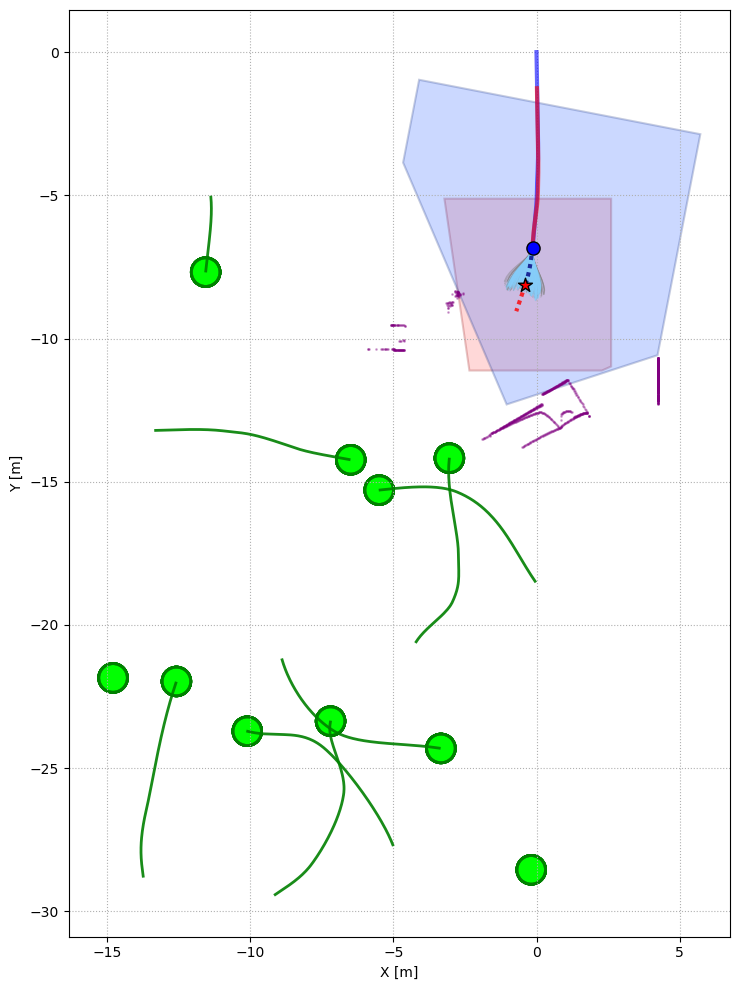

In [9]:
# -------------------- 플로팅 --------------------
fig = plt.figure(figsize=(10,10))
ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
# ax.set_title(f"Snapshot + last {PATH_WINDOW_SEC:.1f}s paths at t={t_query:.2f}s ({TARGET_FRAME})")

plot_idx = 200

# raw (얇은 회색)
for seg in raw_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        ax.plot(seg[:,0], seg[:,1], linewidth=0.6, alpha=0.4, color='#808080' , zorder=10)

# feasible (얇은 하늘색)
for seg in feas_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        ax.plot(seg[:,0], seg[:,1], linewidth=0.8, alpha=0.5, color='#87CEFA', zorder=12)



# best (진한 파랑)
seg = best_segs_xy[plot_idx]
ax.plot(seg[:,0], seg[:,1], linewidth=3.0, alpha=0.8, color='navy', linestyle=(0,(1.0,1.0)), zorder=14, label="Best trajectory")

# target best (진한 빨강)
seg = target_best_segs_xy[plot_idx]
ax.plot(seg[:,0], seg[:,1], linewidth=3.0, alpha=0.8, color='red', linestyle=(0,(1.0,1.0)), zorder=14, label="Target best trajectory")

# corridors (면 제약 반영된 정확한 폴리곤)
def draw_polys(ax, polys, label=None, face=None, edge='k', alpha=0.25):
    used = False
    # for poly in polys:
    poly = np.asarray(polys)
    if poly.ndim != 2 or poly.shape[1] != 2 or len(poly) < 3:
        return
    xs = list(poly[:,0]) + [poly[0,0]]
    ys = list(poly[:,1]) + [poly[0,1]]
    ax.fill(xs, ys, facecolor=face, edgecolor=edge, alpha=alpha,
            linewidth=1.5, label=(label if not used else None))
    used = True

draw_polys(ax, corridorT_polys[plot_idx], label="Target corridor",
           face=(1.0, 0.4, 0.4), edge=(0.6, 0.1, 0.1), alpha=0.25)

draw_polys(ax, corridorR_polys[plot_idx], label="Robot corridor",
           face=(0.2, 0.4, 1.0), edge=(0.1, 0.2, 0.5), alpha=0.25)

# 동적 장애물
for i in range(10):
    pts = np.asarray(dyn_paths_xy_arr[:plot_idx,i], dtype=float)
    if pts.size > 0:
        ax.plot(pts[:,0], pts[:,1], color='green', linewidth=2.0, alpha=0.9, label=('Dyn path' if i==0 else None))

    for x, y in dyn_paths_xy_arr[plot_idx]:
        ax.add_patch(Circle((x,y), CYL_RADIUS, facecolor=(0.0,1.0,0.0,0.35), edgecolor='green', linewidth=2.0))

# 로봇/타겟 경로 + 현재 위치
P = np.asarray(robot_path_xy[:plot_idx], dtype=float); ax.plot(P[:,0], P[:,1], color='blue', linewidth=3.0, alpha=0.6, label='Robot path')
P = np.asarray(target_path_xy[:plot_idx], dtype=float); ax.plot(P[:,0], P[:,1], color='red', linewidth=3.0, alpha=0.6, label='Target path')
ax.scatter([robot_path_xy[plot_idx][0]],[robot_path_xy[plot_idx][1]], s=90, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')
ax.scatter([target_path_xy[plot_idx][0]],[target_path_xy[plot_idx][1]], s=110, marker='*', color='red', edgecolors='k', zorder=100, label='Target')

# LiDAR 포인트 클라우드
P = pcl_data[plot_idx]
if P is not None and P.shape[0] > 0:
    ax.scatter(P[:,0], P[:,1], s=1.0, color='purple', alpha=0.3, label='Lidar points', zorder=5)

# ---- Info prints ----
# _cnt = lambda segs: sum(1 for s in (segs or []) if s is not None and len(s) > 0)
# print(f"[INFO] feasible segments: {_cnt(feas_segs_xy)}")
# print(f"[INFO] raw segments: {_cnt(raw_segs_xy)}")
# print(f"[INFO] best segments: {_cnt(best_segs_xy)}")
# print(f"[INFO] target_best segments: {_cnt(target_best_segs_xy)}")
# print(f"[INFO] corridorT polygons: {len(corridorT_polys)} | corridorR polygons: {len(corridorR_polys)}")
# print(f"[INFO] obstacles_now (shape): {obstacles_xy.shape if obstacles_xy is not None else (0,0)}")
# print(f"[INFO] robot_path_pts(last {PATH_WINDOW_SEC}s): {len(robot_path_xy)} | target_path_pts(last {PATH_WINDOW_SEC}s): {len(target_path_xy)}")
# print(f"[INFO] dyn_paths total pts(last {PATH_WINDOW_SEC}s): {sum(len(p) for p in dyn_paths_xy_arr)}")
# ax.legend(loc='best'); 
ax.grid(True, linestyle=':')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.tight_layout(); plt.show()

# 디버그: 비었을 때 로그
# if not feas_segs_xy:
#     print("[WARN] feasible segs empty - check topic/time")
# if not raw_segs_xy:
#     print("[WARN] raw segs empty - check topic/time")
# if not best_segs_xy:
#     print("[WARN] robot best segs empty - check topic/time")
# if not target_best_segs_xy:
#     print("[WARN] target best segs empty - check topic/time")


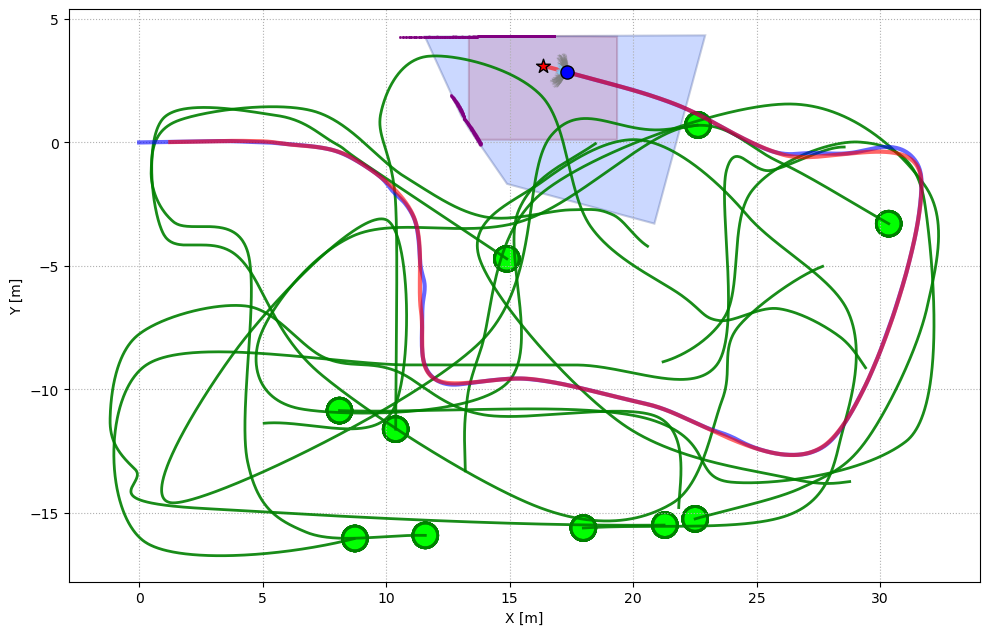

In [10]:
# rotate 90 deg

# -------------------- 플로팅 --------------------
fig = plt.figure(figsize=(10,10))
ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
# ax.set_title(f"Snapshot + last {PATH_WINDOW_SEC:.1f}s paths at t={t_query:.2f}s ({TARGET_FRAME})")

plot_idx = len(robot_path_xy)-1

# raw (얇은 회색)
for seg in raw_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        ax.plot(-seg[:,1], seg[:,0], linewidth=0.6, alpha=0.4, color='#808080' , zorder=10)

# feasible (얇은 하늘색)
for seg in feas_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        ax.plot(-seg[:,1], seg[:,0], linewidth=0.8, alpha=0.5, color='#87CEFA', zorder=12)



# best (진한 파랑)
seg = best_segs_xy[plot_idx]
ax.plot(-seg[:,1], seg[:,0], linewidth=3.0, alpha=0.8, color='navy', linestyle=(0,(1.0,1.0)), zorder=14, label="Best trajectory")

# target best (진한 빨강)
seg = target_best_segs_xy[plot_idx]
ax.plot(-seg[:,1], seg[:,0], linewidth=3.0, alpha=0.8, color='red', linestyle=(0,(1.0,1.0)), zorder=14, label="Target best trajectory")

# corridors (면 제약 반영된 정확한 폴리곤)
def draw_polys(ax, polys, label=None, face=None, edge='k', alpha=0.25):
    used = False
    # for poly in polys:
    poly = np.asarray(polys)
    if poly.ndim != 2 or poly.shape[1] != 2 or len(poly) < 3:
        return
    ys = list(poly[:,0]) + [poly[0,0]]
    xs = list(-poly[:,1]) + [-poly[0,1]]
    ax.fill(xs, ys, facecolor=face, edgecolor=edge, alpha=alpha,
            linewidth=1.5, label=(label if not used else None))
    used = True

draw_polys(ax, corridorT_polys[plot_idx], label="Target corridor",
           face=(1.0, 0.4, 0.4), edge=(0.6, 0.1, 0.1), alpha=0.25)

draw_polys(ax, corridorR_polys[plot_idx], label="Robot corridor",
           face=(0.2, 0.4, 1.0), edge=(0.1, 0.2, 0.5), alpha=0.25)

# 동적 장애물
for i in range(10):
    pts = np.asarray(dyn_paths_xy_arr[:plot_idx,i], dtype=float)
    if pts.size > 0:
        ax.plot(-pts[:,1], pts[:,0], color='green', linewidth=2.0, alpha=0.9, label=('Dyn path' if i==0 else None))

    for x, y in dyn_paths_xy_arr[plot_idx]:
        ax.add_patch(Circle((-y, x), CYL_RADIUS, facecolor=(0.0,1.0,0.0,0.35), edgecolor='green', linewidth=2.0))

# 로봇/타겟 경로 + 현재 위치
P = np.asarray(robot_path_xy[:plot_idx], dtype=float); ax.plot(-P[:,1], P[:,0], color='blue', linewidth=3.0, alpha=0.6, label='Robot path')
P = np.asarray(target_path_xy[:plot_idx], dtype=float); ax.plot(-P[:,1], P[:,0], color='red', linewidth=3.0, alpha=0.6, label='Target path')
ax.scatter([-robot_path_xy[plot_idx][1]],[robot_path_xy[plot_idx][0]], s=90, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')
ax.scatter([-target_path_xy[plot_idx][1]],[target_path_xy[plot_idx][0]], s=110, marker='*', color='red', edgecolors='k', zorder=100, label='Target')

# LiDAR 포인트 클라우드
P = pcl_data[plot_idx]
if P is not None and P.shape[0] > 0:
    ax.scatter(-P[:,1], P[:,0], s=1.0, color='purple', alpha=0.3, label='Lidar points', zorder=5)

ax.grid(True, linestyle=':')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.tight_layout(); plt.show()


In [45]:

mesh = copy.deepcopy(mesh_origin)    
# mesh에서 특정 높이만큼 자르기
z_min, z_max = 0, 300
x_min, x_max = -1100, 1800
y_min, y_max = -1200, 750
bbox = o3d.geometry.AxisAlignedBoundingBox(min_bound=(x_min, y_min, z_min), max_bound=(x_max, y_max, z_max))
mesh = mesh.crop(bbox)

# mesh 에 높이에 따른 색 입히기
z_values = np.asarray(mesh.vertices)[:, 2]
z_norm = (z_values - z_min) / (z_max - z_min + 1e-8)  # 0~1 정규화
# colors = plt.cm.viridis(z_norm)[:, :3]  # viridis 컬러맵에서 RGB 추출
colors = plt.cm.get_cmap('jet')(z_norm)[:, :3]  # jet 컬러맵에서 RGB 추출
mesh.vertex_colors = o3d.utility.Vector3dVector(colors)


x_offset = 717.464 - (-215.0)
y_offset = -287.73 - 68.4938

mesh = mesh.translate((x_offset, y_offset, 0))
mesh = mesh.rotate(o3d.geometry.get_rotation_matrix_from_xyz((0, 0, -np.deg2rad(90))), center=(0,0,0))


# pcl from mesh
pcd = mesh.sample_points_poisson_disk(number_of_points=20000)
# pcd = mesh.sample_points_uniformly(number_of_points=300000)
# pcd = mesh.sample_points_uniformly(number_of_points=1000000)
# pcd = mesh.sample_points_poisson_disk(number_of_points=1000000)


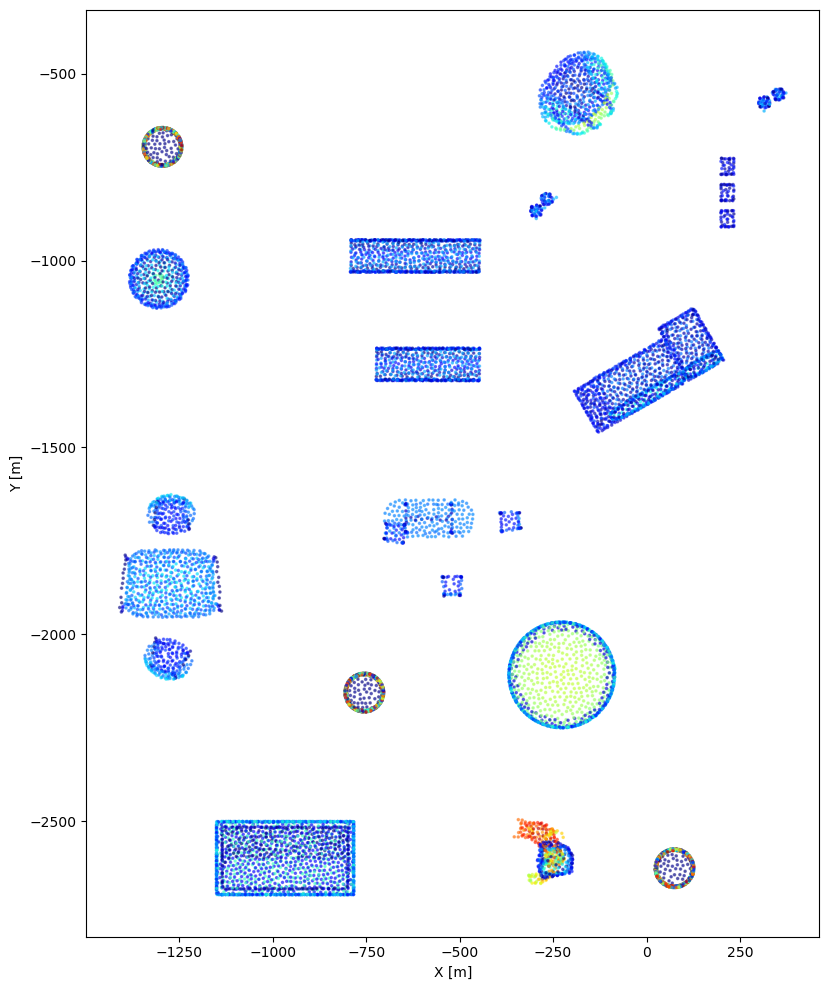

In [40]:

# plot pcd with plt
pts = np.asarray(pcd.points)
fig = plt.figure(figsize=(10,10))
ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
# 높이에 따른 색상
z_vals = pts[:,2]
z_min, z_max = np.min(z_vals), np.max(z_vals)
z_norm = (z_vals - z_min) / (z_max - z_min + 1e-8)
colors = plt.cm.get_cmap('jet')(z_norm)[:, :3]  # jet 컬러맵에서 RGB 추출
ax.scatter(pts[:,0], pts[:,1], s=10, color=colors, alpha=0.5, label='Map points', zorder=1, marker='.')
# ax.scatter(pts[:,0], pts[:,1], s=0.5, color='gray', alpha=0.3, label='Map points', zorder=1)
# ax.scatter(-pts[:,1], pts[:,0], s=0.5, color='gray', alpha=0.3, label='Map points', zorder=1)
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.tight_layout(); plt.show()
# plot pcd with o3d

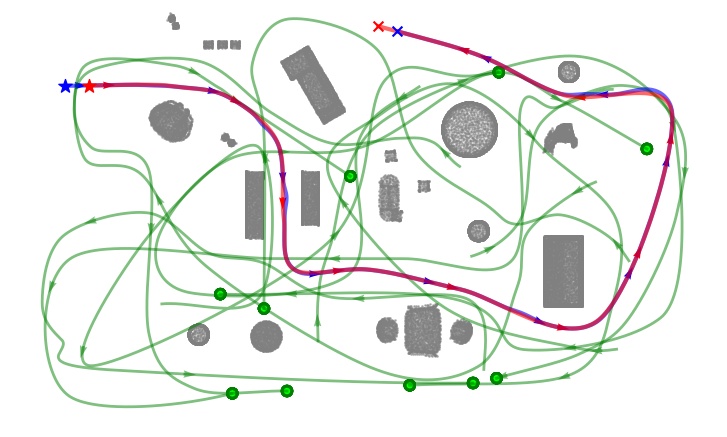

In [133]:
# rotate 90 deg

# -------------------- 플로팅 --------------------
fig = plt.figure(figsize=((34.04 + 2.85)/5, (17.78 + 5.38)/5))
ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
# ax.set_title(f"Snapshot + last {PATH_WINDOW_SEC:.1f}s paths at t={t_query:.2f}s ({TARGET_FRAME})")

plot_idx = len(robot_path_xy)-1

# # raw (얇은 회색)
# for seg in raw_segs_xy[plot_idx] or []:
#     if seg is not None and len(seg) > 0:
#         ax.plot(-seg[:,1], seg[:,0], linewidth=0.6, alpha=0.4, color='#808080' , zorder=10)

# # feasible (얇은 하늘색)
# for seg in feas_segs_xy[plot_idx] or []:
#     if seg is not None and len(seg) > 0:
#         ax.plot(-seg[:,1], seg[:,0], linewidth=0.8, alpha=0.5, color='#87CEFA', zorder=12)



# best (진한 파랑)
# seg = best_segs_xy[plot_idx]
# ax.plot(-seg[:,1], seg[:,0], linewidth=3.0, alpha=0.8, color='navy', linestyle=(0,(1.0,1.0)), zorder=14, label="Best trajectory")

# target best (진한 빨강)
# seg = target_best_segs_xy[plot_idx]
# ax.plot(-seg[:,1], seg[:,0], linewidth=3.0, alpha=0.8, color='red', linestyle=(0,(1.0,1.0)), zorder=14, label="Target best trajectory")

# corridors (면 제약 반영된 정확한 폴리곤)
def draw_polys(ax, polys, label=None, face=None, edge='k', alpha=0.25):
    used = False
    # for poly in polys:
    poly = np.asarray(polys)
    if poly.ndim != 2 or poly.shape[1] != 2 or len(poly) < 3:
        return
    ys = list(poly[:,0]) + [poly[0,0]]
    xs = list(-poly[:,1]) + [-poly[0,1]]
    ax.fill(xs, ys, facecolor=face, edgecolor=edge, alpha=alpha,
            linewidth=1.5, label=(label if not used else None))
    used = True

# draw_polys(ax, corridorT_polys[plot_idx], label="Target corridor",
#            face=(1.0, 0.4, 0.4), edge=(0.6, 0.1, 0.1), alpha=0.25)

# draw_polys(ax, corridorR_polys[plot_idx], label="Robot corridor",
#            face=(0.2, 0.4, 1.0), edge=(0.1, 0.2, 0.5), alpha=0.25)

# 동적 장애물
for i in range(10):
    pts = np.asarray(dyn_paths_xy_arr[:plot_idx,i], dtype=float)
    if pts.size > 0:
        ax.plot(-pts[:,1], pts[:,0], color='green', linewidth=2.0, alpha=0.5, label=('Dyn path' if i==0 else None))

    for x, y in dyn_paths_xy_arr[plot_idx]:
        ax.add_patch(Circle((-y, x), CYL_RADIUS/2, facecolor=(0.0,1.0,0.0,0.35), edgecolor='green', linewidth=2.0))

# 로봇/타겟 경로 + 현재 위치
P = np.asarray(robot_path_xy[:plot_idx], dtype=float); ax.plot(-P[:,1], P[:,0], color='blue', linewidth=3.0, alpha=0.6, label='Robot path')
P = np.asarray(target_path_xy[:plot_idx], dtype=float); ax.plot(-P[:,1], P[:,0], color='red', linewidth=3.0, alpha=0.6, label='Target path')
# ax.scatter([-robot_path_xy[plot_idx][1]],[robot_path_xy[plot_idx][0]], s=100, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')
# ax.scatter([-target_path_xy[plot_idx][1]],[target_path_xy[plot_idx][0]], s=130, marker='*', color='red', edgecolors='k', zorder=100, label='Target')

# plot arrow for direction
arrow_interval = 200
for i in range(20, len(robot_path_xy), arrow_interval):
    if i + 1 < len(robot_path_xy):
        dir = np.array(robot_path_xy[i+1]-robot_path_xy[i])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(-robot_path_xy[i][1], robot_path_xy[i][0], -dir[1], dir[0],
                     scale=8, scale_units='inches', width=0.005, color='b')
for i in range(20, len(target_path_xy), arrow_interval):
    if i + 1 < len(target_path_xy):
        dir = np.array(target_path_xy[i+1]-target_path_xy[i])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(-target_path_xy[i][1], target_path_xy[i][0], -dir[1], dir[0],
                     scale=8, scale_units='inches', width=0.005, color='r')

arrow_interval = 500
for j in range(10):
    for i in range(20, len(dyn_paths_xy_arr), arrow_interval):
        if i + 1 < len(dyn_paths_xy_arr) and dyn_paths_xy_arr[i,j] is not None and dyn_paths_xy_arr[i+1,j] is not None:
            dir = np.array(dyn_paths_xy_arr[i+1,j]-dyn_paths_xy_arr[i,j])
            if np.linalg.norm(dir) > 1e-3:
                dir = dir / np.linalg.norm(dir) * 1
                plt.quiver(-dyn_paths_xy_arr[i,j][1], dyn_paths_xy_arr[i,j][0], -dir[1], dir[0],
                             scale=8, scale_units='inches', width=0.005, color='g', alpha=0.5)

# plot start and end point
ax.scatter([-robot_path_xy[0][1]],[robot_path_xy[0][0]], s=100, marker='*', color='b', zorder=100, label='Robot start')
ax.scatter([-target_path_xy[0][1]],[target_path_xy[0][0]], s=100, marker='*', color='r', zorder=100, label='Target start')
ax.scatter([-robot_path_xy[-1][1]],[robot_path_xy[-1][0]], s=50, marker='x', color='b', zorder=100, label='Robot end')
ax.scatter([-target_path_xy[-1][1]],[target_path_xy[-1][0]], s=50, marker='x', color='r', zorder=100, label='Target end')

# LiDAR 포인트 클라우드
# P = pcl_data[plot_idx]
# if P is not None and P.shape[0] > 0:
#     ax.scatter(-P[:,1], P[:,0], s=1.0, color='purple', alpha=0.3, label='Lidar points', zorder=5)

# mesh points
P = np.asarray(pcd.points)/100
if P is not None and P.shape[0] > 0:
    ax.scatter(-P[:,1], P[:,0], s=1.0, color='gray', alpha=0.5, label='Mesh points', zorder=1)

ax.grid(False)
ax.set_xlim(-2.8547247111797334, 34.049241012334825)
ax.set_ylim(-17.787881394141507, 4)
# plt.xlabel('X [m]'); plt.ylabel('Y [m]')
ax.axis('off')
plt.tight_layout();
plt.savefig("top_down_view.pdf", dpi=300, bbox_inches='tight', pad_inches=0.1)

# print(ax.get_xlim(),    ax.get_ylim())

INFO - 2025-10-02 12:31:26,916 - animation - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO - 2025-10-02 12:31:26,917 - animation - figure size (inches) has been adjusted from 7.378 x 4.356 to 7.37 x 4.3500000000000005
INFO - 2025-10-02 12:31:26,917 - animation - MovieWriter.run: running command: ['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1474x870', '-pix_fmt', 'rgba', '-r', '29.999999999999996', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'robot_navigation.mp4']


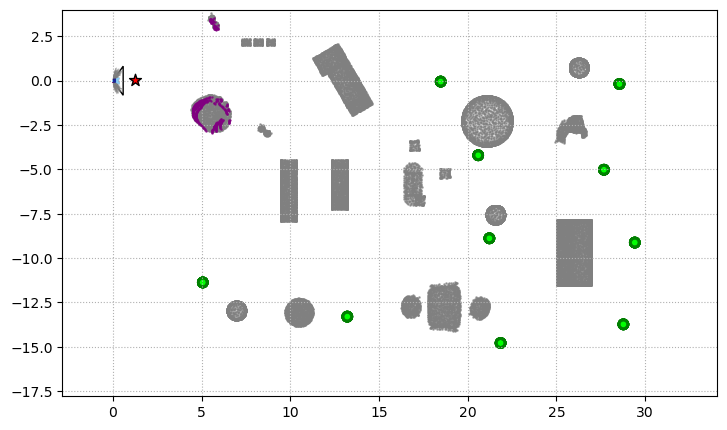

In [141]:
# save as mp4
import matplotlib.animation as animation

fig = plt.figure(figsize=((34.04 + 2.85)/5, (17.78 + 4)/5))

ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
# ax.set_title(f"Snapshot + last {PATH_WINDOW_SEC:.1f}s paths at t={t_query:.2f}s ({TARGET_FRAME})")


fov = 110 * np.pi / 180 / 2
coord_frame = np.array([[0, 0],
                        [np.cos(fov), -np.sin(fov)],
                        [np.cos(fov), np.sin(fov)]]) * 1.0


def update(frame):
    ax.clear()
    ax.set_aspect('equal', adjustable='box')
    plot_idx = frame

    # raw (얇은 회색)
    for seg in raw_segs_xy[plot_idx] or []:
        if seg is not None and len(seg) > 0:
            ax.plot(-seg[:,1], seg[:,0], linewidth=0.6, alpha=0.4, color='#808080' , zorder=10)

    # feasible (얇은 하늘색)
    for seg in feas_segs_xy[plot_idx] or []:
        if seg is not None and len(seg) > 0:
            ax.plot(-seg[:,1], seg[:,0], linewidth=0.8, alpha=0.5, color='#87CEFA', zorder=12)

    # best (진한 파랑)
    seg = best_segs_xy[plot_idx]
    ax.plot(-seg[:,1], seg[:,0], linewidth=3.0, alpha=0.8, color='navy', linestyle=(0,(1.0,1.0)), zorder=14, label="Best trajectory")

    # target best (진한 빨강)
    seg = target_best_segs_xy[plot_idx]
    ax.plot(-seg[:,1], seg[:,0], linewidth=3.0, alpha=0.8, color='red', linestyle=(0,(1.0,1.0)), zorder=14, label="Target best trajectory")

    # draw_polys(ax, corridorT_polys[plot_idx], label="Target corridor",
    #         face=(1.0, 0.4, 0.4), edge=(0.6, 0.1, 0.1), alpha=0.25)

    # draw_polys(ax, corridorR_polys[plot_idx], label="Robot corridor",
    #         face=(0.2, 0.4, 1.0), edge=(0.1, 0.2, 0.5), alpha=0.25)

    # 동적 장애물
    for i in range(10):
        pts = np.asarray(dyn_paths_xy_arr[max(0, plot_idx-100):plot_idx,i], dtype=float)
        if pts.size > 0:
            ax.plot(-pts[:,1], pts[:,0], color='green', linewidth=2.0, alpha=0.5, label=('Dyn path' if i==0 else None))

        for x, y in dyn_paths_xy_arr[plot_idx]:
            ax.add_patch(Circle((-y, x), CYL_RADIUS/2, facecolor=(0.0,1.0,0.0,0.35), edgecolor='green', linewidth=2.0))

    # 로봇/타겟 경로 + 현재 위치
    P = np.asarray(robot_path_xy[:plot_idx], dtype=float); ax.plot(-P[:,1], P[:,0], color='blue', linewidth=3.0, alpha=0.6, label='Robot path')
    P = np.asarray(target_path_xy[:plot_idx], dtype=float); ax.plot(-P[:,1], P[:,0], color='red', linewidth=3.0, alpha=0.6, label='Target path')
    # ax.scatter([-robot_path_xy[plot_idx][1]],[robot_path_xy[plot_idx][0]], s=100, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')
    ax.scatter([-target_path_xy[plot_idx][1]],[target_path_xy[plot_idx][0]], s=80, marker='*', color='red', edgecolors='k', zorder=100, label='Target')

    # camera fov 표시
    yaw = robot_path_yaw[plot_idx]
    R = np.array([[np.cos(yaw), -np.sin(yaw)],
                  [np.sin(yaw),  np.cos(yaw)]])
    fov_rotated = (R @ coord_frame.T).T + np.array([robot_path_xy[plot_idx][0], robot_path_xy[plot_idx][1]])
    ax.fill(-fov_rotated[:,1], fov_rotated[:,0], edgecolor='k', linewidth=1, fill=False)

    # LiDAR 포인트 클라우드
    P = pcl_data[plot_idx]
    if P is not None and P.shape[0] > 0:
        ax.scatter(-P[:,1], P[:,0], s=0.7, color='purple', alpha=0.7, label='Lidar points', zorder=5)

    # mesh points
    P = np.asarray(pcd.points)/100
    if P is not None and P.shape[0] > 0:
        ax.scatter(-P[:,1], P[:,0], s=0.7, color='gray', alpha=0.7, label='Mesh points', zorder=1)

    ax.grid(True, linestyle=':')
    ax.set_xlim(-2.8547247111797334, 34.049241012334825)
    ax.set_ylim(-17.787881394141507, 4)
    plt.tight_layout()

fps = 30
ani = animation.FuncAnimation(fig, update, frames=len(robot_path_xy), interval=1000/fps)
ani.save('robot_navigation.mp4', writer='ffmpeg', dpi=200)


In [ ]:
# # plot in open3d (TBD)

# from numpy import mat


# def cylinder_between(p0, p1, radius=0.01, resolution=20):
#     p0, p1 = np.asarray(p0), np.asarray(p1)
#     v = p1 - p0
#     h = np.linalg.norm(v)
#     if h < 1e-9:
#         return None
#     # 기본 z축 방향 실린더 생성
#     cyl = o3d.geometry.TriangleMesh.create_cylinder(radius=radius, height=h, resolution=resolution)
#     cyl.compute_vertex_normals()

#     # z축 -> v 방향 회전
#     z = np.array([0,0,1.0]); vdir = v / h
#     axis = np.cross(z, vdir); c = np.dot(z, vdir)
#     if np.linalg.norm(axis) < 1e-9:
#         R = np.eye(3) if c > 0 else o3d.geometry.get_rotation_matrix_from_axis_angle([1,0,0, np.pi])
#     else:
#         angle = np.arctan2(np.linalg.norm(axis), c)
#         axis = axis / np.linalg.norm(axis)
#         R = o3d.geometry.get_rotation_matrix_from_axis_angle(axis * angle)

#     # 가운데 정렬 → p0에서 p1로 이동
#     cyl.rotate(R, center=np.zeros(3))
#     cyl.translate(p0 + v * 0.5)
#     return cyl

# mesh = copy.deepcopy(mesh_origin)    
# # mesh에서 특정 높이만큼 자르기
# z_min, z_max = 0, 300
# x_min, x_max = -1100, 1800
# y_min, y_max = -1200, 750
# bbox = o3d.geometry.AxisAlignedBoundingBox(min_bound=(x_min, y_min, z_min), max_bound=(x_max, y_max, z_max))
# mesh = mesh.crop(bbox)

# # mesh 에 높이에 따른 색 입히기
# z_values = np.asarray(mesh.vertices)[:, 2]
# z_norm = (z_values - z_min) / (z_max - z_min + 1e-8)  # 0~1 정규화
# # colors = plt.cm.viridis(z_norm)[:, :3]  # viridis 컬러맵에서 RGB 추출
# colors = plt.cm.get_cmap('jet')(z_norm)[:, :3]  # jet 컬러맵에서 RGB 추출
# mesh.vertex_colors = o3d.utility.Vector3dVector(colors)


# x_offset = 717.464 - (-215.0)
# y_offset = -287.73 - 68.4938

# mesh = mesh.translate((x_offset, y_offset, 0))
# mesh = mesh.rotate(o3d.geometry.get_rotation_matrix_from_xyz((0, 0, -np.deg2rad(90))), center=(0,0,0))

# path_plot_height = 0.8
# target_path_line_set = []
# robot_path_line_set = []
# dynamic_obs_line_set = []

# end_points = []


# sphere_radius = 0.2


# # draw robot path
# if len(robot_path_xy) > 1:
#     path_pts = np.array(robot_path_xy, dtype=float)
#     path_pts_3d = np.hstack((path_pts, np.ones((path_pts.shape[0], 1), dtype=float) * path_plot_height)) * 100
#     # path_pts_3d[:,0] += x_offset
#     # path_pts_3d[:,1] += y_offset
#     # line with thickness
#     for i in range(len(path_pts_3d)-1):
#         cyl = cylinder_between(path_pts_3d[i], path_pts_3d[i+1], radius=sphere_radius*100/3, resolution=10)
#         if cyl is not None:
#             cyl.paint_uniform_color([0.0, 0.0, 1.0])
#             robot_path_line_set.append(cyl)
#     # path_line = o3d.geometry.LineSet()
#     # path_line.points = o3d.utility.Vector3dVector(path_pts_3d)
#     # path_line.lines = o3d.utility.Vector2iVector([[i, i+1] for i in range(len(path_pts_3d)-1)])
#     # path_line.colors = o3d.utility.Vector3dVector([[0, 0, 1] for _ in range(len(path_pts_3d)-1)])  # 파란색

#     # path_line_set.append(path_line)

#     cyl = o3d.geometry.TriangleMesh.create_sphere(radius=sphere_radius*100)
#     cyl.compute_vertex_normals()
#     cyl.paint_uniform_color([0.0, 0.0, 1.0])
#     cyl = cyl.translate((path_pts_3d[-1,0], path_pts_3d[-1,1], path_plot_height*100))
#     robot_path_line_set.append(cyl)

# # draw target path
# if len(target_path_xy) > 1:
#     path_pts = np.array(target_path_xy, dtype=float)
#     path_pts_3d = np.hstack((path_pts, np.ones((path_pts.shape[0], 1), dtype=float) * path_plot_height)) * 100
    
#     # path_line = o3d.geometry.LineSet()
#     for i in range(len(path_pts_3d)-1):
#         cyl = cylinder_between(path_pts_3d[i], path_pts_3d[i+1], radius=sphere_radius*100/3, resolution=10)
#         if cyl is not None:
#             cyl.paint_uniform_color([0.0, 0.0, 1.0])
#             target_path_line_set.append(cyl)

    
#     cyl = o3d.geometry.TriangleMesh.create_sphere(radius=sphere_radius*100)
#     cyl.compute_vertex_normals()
#     cyl.paint_uniform_color([1.0, 0.0, 0.0])
#     cyl = cyl.translate((path_pts_3d[-1,0], path_pts_3d[-1,1], path_plot_height*100))
#     target_path_line_set.append(cyl)

# # draw dynamic obstacles
# for i in range(10):
#     pts = np.asarray(dyn_paths_xy_arr[:,i], dtype=float)
#     if pts.size > 0:
#         pts_3d = np.hstack((pts, np.ones((pts.shape[0], 1), dtype=float) * path_plot_height)) * 100
#         # pts_3d[:,0] += x_offset
#         # pts_3d[:,1] += y_offset
#         # path_line = o3d.geometry.LineSet()
#         # path_line.points = o3d.utility.Vector3dVector(pts_3d)
#         # path_line.lines = o3d.utility.Vector2iVector([[j, j+1] for j in range(len(pts_3d)-1)])
#         # path_line.colors = o3d.utility.Vector3dVector([[0, 1, 0] for _ in range(len(pts_3d)-1)])  # 초록색
#         for j in range(len(pts_3d)-1):
#             cyl = cylinder_between(pts_3d[j], pts_3d[j+1], radius=sphere_radius*100/3, resolution=10)
#             if cyl is not None:
#                 cyl.paint_uniform_color([0.0, 1.0, 0.0])
#                 dynamic_obs_line_set.append(cyl)
        


#     for x, y in dyn_paths_xy_arr[-1]:
#         x = x * 100
#         y = y * 100
#         cyl = o3d.geometry.TriangleMesh.create_sphere(radius=sphere_radius*100)
#         cyl.compute_vertex_normals()
#         cyl.paint_uniform_color([0.0, 1.0, 0.0])
#         cyl = cyl.translate((x, y, path_plot_height*100))
#         dynamic_obs_line_set.append(cyl)

# o3d.visualization.draw_geometries([mesh,coord, *target_path_line_set, *robot_path_line_set, *dynamic_obs_line_set],
#                                   window_name="Environment with Paths",
#                                   width=1280, height=720,
#                                   mesh_show_back_face=True)

# # target_mat = o3d.visualization.rendering.MaterialRecord()
# # target_mat.shader = "defaultLitTransparency"
# # target_mat.base_color = (1.0, 0.0, 0.0, 0.35)  # RGBA, A=0.35 불투명도
# # target_mat.metallic = 0.0
# # target_mat.roughness = 0.5

# # robot_mat = o3d.visualization.rendering.MaterialRecord()
# # robot_mat.shader = "defaultLitTransparency"
# # robot_mat.base_color = (0.0, 0.0, 1.0, 0.35)  # RGBA, A=0.35 불투명도
# # robot_mat.metallic = 0.0
# # robot_mat.roughness = 0.5

# # dyna_mat = o3d.visualization.rendering.MaterialRecord()
# # dyna_mat.shader = "defaultLitTransparency"
# # dyna_mat.base_color = (0.0, 1.0, 0.0, 0.35)  # RGBA, A=0.35 불투명도
# # dyna_mat.metallic = 0.0
# # dyna_mat.roughness = 0.5

# # w, h = 1024, 768
# # renderer = o3d.visualization.rendering.OffscreenRenderer(w, h)
# # scene = renderer.scene
# # scene.set_background([1,1,1,0])  # 흰 배경

# # scene.add_geometry("mesh", mesh, o3d.visualization.rendering.MaterialRecord())
# # scene.add_geometry("coord", coord, o3d.visualization.rendering.MaterialRecord())
# # for i, cyl in enumerate(target_path_line_set):
# #     scene.add_geometry(f"target_path_{i}", cyl, target_mat)
# # for i, cyl in enumerate(robot_path_line_set):
# #     scene.add_geometry(f"robot_path_{i}", cyl, robot_mat)
# # for i, cyl in enumerate(dynamic_obs_line_set):
# #     scene.add_geometry(f"dyna_obs_{i}", cyl, dyna_mat)

# # # 카메라 설정
# # cam = scene.camera
# # # cam.look_at([717.464, -287.73, 0], [717.464, -287.73, 100], [0,0,1])
# # cam.look_at([717.464 + x_offset, -287.73 + y_offset, 0], [717.464 + x_offset, -287.73 + y_offset, 100], [0,0,1])
# # cam.set_projection(60.0, w/h, 0.1, 1000.0)
# # # cam.set_projection(60.0, w/h, 0.1, 1000.0, o3d.visualization.rendering.Camera.FovType.Vertical)
# # cam.set_zoom(0.5)
# # # cam.set_view_matrix(np.array([[ 0.866, -0.5  ,  0.   , 717.464 + x_offset],
# # #                              [ 0.5  ,  0.866,  0.   , -287.73 + y_offset],
# # #                              [ 0.   ,  0.   ,  1.   , 200.0       ],
# # #                              [ 0.   ,  0.   ,  0.   , 1.          ]], dtype=float))

# # img = renderer.render_to_image()
# # o3d.io.write_image("snapshot.png", img)



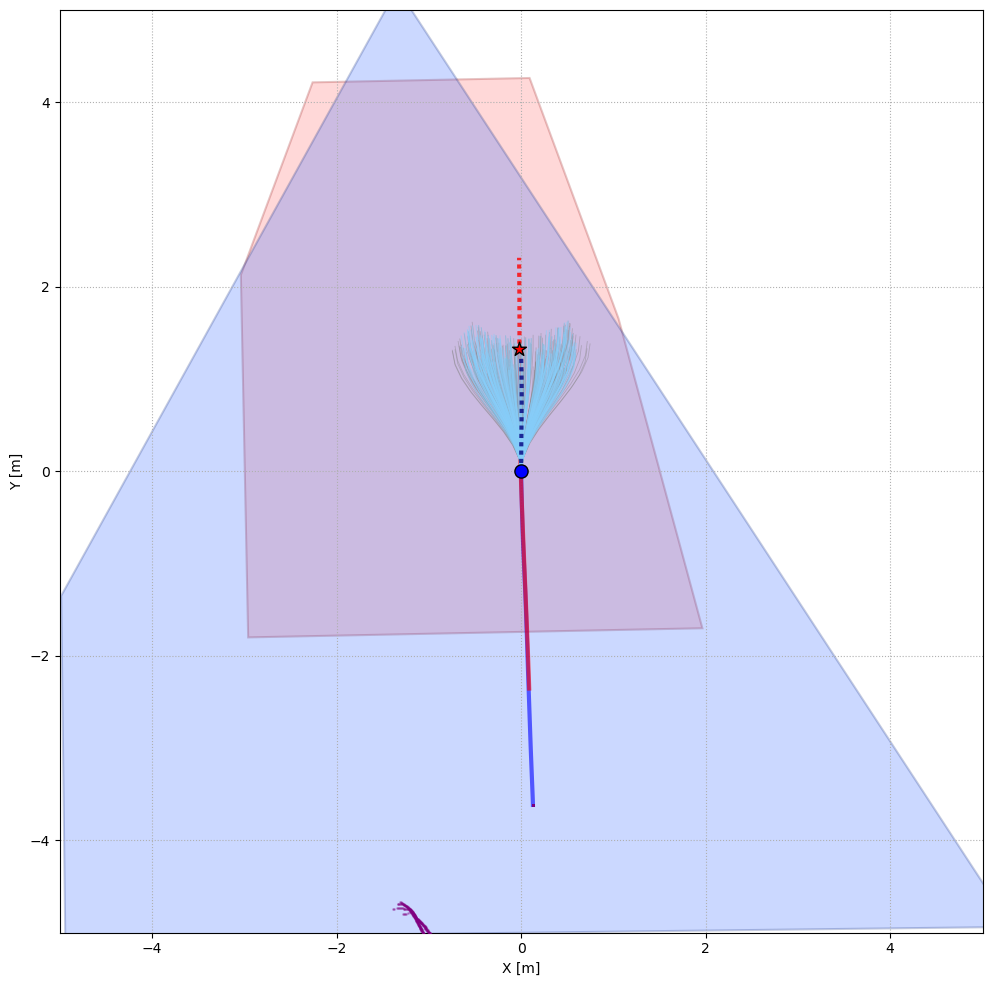

In [117]:
# plot at robot frame
fig = plt.figure(figsize=(10,10))
ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
# ax.set_title(f"Snapshot + last {PATH_WINDOW_SEC:.1f}s paths at t={t_query:.2f}s ({TARGET_FRAME})")
plot_idx = 100
yaw = robot_path_yaw[plot_idx] - np.pi/2  # x축이 로봇 진행 방향이 되도록 90도 회전
R_robot = np.array([[np.cos(-yaw), -np.sin(-yaw)],
                    [np.sin(-yaw),  np.cos(-yaw)]])
t_robot = -R_robot @ robot_path_xy[plot_idx]

# raw (얇은 회색)
for seg in raw_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        P = (R_robot @ seg.T).T + t_robot
        ax.plot(P[:,0], P[:,1], linewidth=0.6, alpha=0.4, color='#808080' , zorder=10)  

# feasible (얇은 하늘색)
for seg in feas_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        P = (R_robot @ seg.T).T + t_robot
        ax.plot(P[:,0], P[:,1], linewidth=0.8, alpha=0.5, color='#87CEFA', zorder=12)
# best (진한 파랑)
seg = best_segs_xy[plot_idx]
P = (R_robot @ seg.T).T + t_robot
ax.plot(P[:,0], P[:,1], linewidth=3.0, alpha=0.8, color='navy', linestyle=(0,(1.0,1.0)), zorder=14, label="Best trajectory")
# target best (진한 빨강)
seg = target_best_segs_xy[plot_idx]
P = (R_robot @ seg.T).T + t_robot
ax.plot(P[:,0], P[:,1], linewidth=3.0, alpha=0.8, color='red', linestyle=(0,(1.0,1.0)), zorder=14, label="Target best trajectory")
# corridors (면 제약 반영된 정확한 폴리곤)
def draw_polys(ax, polys, label=None, face=None, edge='k', alpha=0.25):
    used = False
    # for poly in polys:
    poly = np.asarray(polys)
    if poly.ndim != 2 or poly.shape[1] != 2 or len(poly) < 3:
        return
    P = (R_robot @ poly.T).T + t_robot
    xs = list(P[:,0]) + [P[0,0]]
    ys = list(P[:,1]) + [P[0,1]]
    ax.fill(xs, ys, facecolor=face, edgecolor=edge, alpha=alpha,
            linewidth=1.5, label=(label if not used else None))
    used = True

draw_polys(ax, corridorT_polys[plot_idx], label="Target corridor",
           face=(1.0, 0.4, 0.4), edge=(0.6, 0.1, 0.1), alpha=0.25)
draw_polys(ax, corridorR_polys[plot_idx], label="Robot corridor",
           face=(0.2, 0.4, 1.0), edge=(0.1, 0.2, 0.5), alpha=0.25)

# 동적 장애물
for i in range(10):
    pts = np.asarray(dyn_paths_xy_arr[:plot_idx,i], dtype=float)
    if pts.size > 0:
        P = (R_robot @ pts.T).T + t_robot
        ax.plot(P[:,0], P[:,1], color='green', linewidth=2.0, alpha=0.9, label=('Dyn path' if i==0 else None))

    for x, y in dyn_paths_xy_arr[plot_idx]:
        p = R_robot @ np.array([x,y]) + t_robot
        ax.add_patch(Circle((p[0], p[1]), CYL_RADIUS, facecolor=(0.0,1.0,0.0,0.35), edgecolor='green', linewidth=2.0))

# 로봇/타겟 경로 + 현재 위치
P = np.asarray(robot_path_xy[:plot_idx], dtype=float); P = (R_robot @ P.T).T + t_robot
ax.plot(P[:,0], P[:,1], color='blue', linewidth=3.0, alpha=0.6, label='Robot path')
P = np.asarray(target_path_xy[:plot_idx], dtype=float); P = (R_robot @ P.T).T + t_robot
ax.plot(P[:,0], P[:,1], color='red', linewidth=3.0, alpha=0.6, label='Target path')
ax.scatter(0,0, s=90, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')
p_tgt = R_robot @ target_path_xy[plot_idx] + t_robot
ax.scatter([p_tgt[0]],[p_tgt[1]], s=110, marker='*', color='red', edgecolors='k', zorder=100, label='Target')

# LiDAR 포인트 클라우드
P = pcl_data[plot_idx]
if P is not None and P.shape[0] > 0:
    P[:,:2] = (R_robot @ P[:,:2].T).T + t_robot
    ax.scatter(P[:,0], P[:,1], s=1.0, color='purple', alpha=0.3, label='Lidar points', zorder=5)

ax.grid(True, linestyle=':')
ax.set_xlim(-5,5); ax.set_ylim(-5,5)

plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.tight_layout(); plt.show()

In [71]:
# get image from mp4
import cv2
import os
from datetime import datetime

VIDEO_PATH = "/home/seungwoo/alchemist_ws/src/BPMP-Tracker/script/airsim_results/top_down.mp4"
cap = cv2.VideoCapture(VIDEO_PATH)

file_creation_time = os.path.getctime(VIDEO_PATH)
print(f"File creation time: {datetime.fromtimestamp(file_creation_time)}")


frames = []
timestamps = []

downsample_factor = 2  # 2로 설정하면 해상도 절반

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    # 현재 프레임의 타임스탬프 (밀리초)
    timestamp_ms = cap.get(cv2.CAP_PROP_POS_MSEC)
    timestamp_sec = timestamp_ms / 1000.0
    if downsample_factor > 1:
        frame = cv2.resize(frame, (frame.shape[1] // downsample_factor, frame.shape[0] // downsample_factor))

    frame_absolute_time = file_creation_time + timestamp_sec

    
    frames.append(frame)
    timestamps.append(frame_absolute_time)
    
    print(f"Frame {frame_idx}: {frame_absolute_time:.3f}s")
    frame_idx += 1

cap.release()

frames = np.array(frames)
timestamps = np.array(timestamps)



File creation time: 2025-09-26 05:51:10.402523
Frame 0: 1758833470.386s
Frame 1: 1758833470.419s
Frame 2: 1758833470.436s
Frame 3: 1758833470.453s
Frame 4: 1758833470.469s
Frame 5: 1758833470.486s
Frame 6: 1758833470.503s
Frame 7: 1758833470.519s
Frame 8: 1758833470.536s
Frame 9: 1758833470.553s
Frame 10: 1758833470.569s
Frame 11: 1758833470.586s
Frame 12: 1758833470.603s
Frame 13: 1758833470.619s
Frame 14: 1758833470.636s
Frame 15: 1758833470.653s
Frame 16: 1758833470.669s
Frame 17: 1758833470.686s
Frame 18: 1758833470.703s
Frame 19: 1758833470.719s
Frame 20: 1758833470.736s
Frame 21: 1758833470.753s
Frame 22: 1758833470.769s
Frame 23: 1758833470.786s
Frame 24: 1758833470.803s
Frame 25: 1758833470.819s
Frame 26: 1758833470.836s
Frame 27: 1758833470.853s
Frame 28: 1758833470.869s
Frame 29: 1758833470.886s
Frame 30: 1758833470.903s
Frame 31: 1758833470.919s
Frame 32: 1758833470.936s
Frame 33: 1758833470.953s
Frame 34: 1758833470.969s
Frame 35: 1758833470.986s
Frame 36: 1758833471.003s
F

1758833475.2358565


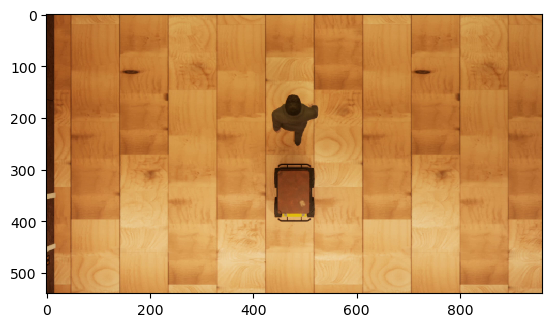

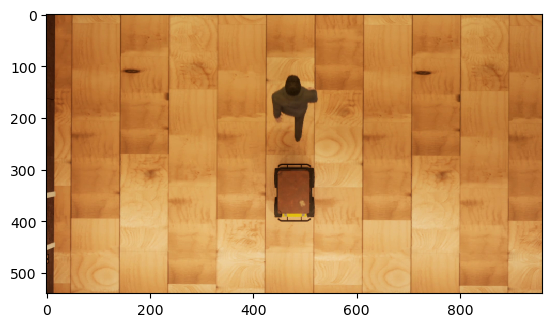

In [72]:
plt.figure()
plt.imshow(frames[0][:,:,::-1])
plt.figure()
plt.imshow(frames[290][:,:,::-1])

print(timestamps[290])

vedio_start_t = timestamps[290]

In [93]:
# sync frames with robot_path_xy based on absolute time
synced_frames = []
time_from_start = robot_t - start_t
time_from_start_video = timestamps - vedio_start_t

for i, t in enumerate(time_from_start):
    diff_t = np.abs(time_from_start_video - t)
    closest_frame_idx = np.argmin(diff_t)
    print(f"Robot time {t:.3f}s (diff {diff_t[closest_frame_idx]:.3f}s) -> Closest frame {closest_frame_idx} at {timestamps[closest_frame_idx]:.3f}s")
    frame = frames[closest_frame_idx]
    synced_frames.append(frame)
    
    # plt.figure(figsize=(8,8))
    # plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    # plt.title(f"Robot time {t:.3f}s (abs {abs_t:.3f}s) -> Closest frame {closest_frame_idx} at {timestamps[closest_frame_idx]:.3f}s")
    # plt.axis('off')
    # plt.show()

Robot time 0.008s (diff 0.008s) -> Closest frame 290 at 1758833475.236s
Robot time 0.046s (diff 0.004s) -> Closest frame 293 at 1758833475.286s
Robot time 0.088s (diff 0.005s) -> Closest frame 295 at 1758833475.319s
Robot time 0.117s (diff 0.000s) -> Closest frame 297 at 1758833475.353s
Robot time 0.149s (diff 0.001s) -> Closest frame 299 at 1758833475.386s
Robot time 0.191s (diff 0.007s) -> Closest frame 301 at 1758833475.419s
Robot time 0.220s (diff 0.004s) -> Closest frame 303 at 1758833475.453s
Robot time 0.256s (diff 0.006s) -> Closest frame 305 at 1758833475.486s
Robot time 0.285s (diff 0.002s) -> Closest frame 307 at 1758833475.519s
Robot time 0.321s (diff 0.004s) -> Closest frame 309 at 1758833475.553s
Robot time 0.345s (diff 0.005s) -> Closest frame 311 at 1758833475.586s
Robot time 0.375s (diff 0.008s) -> Closest frame 312 at 1758833475.603s
Robot time 0.404s (diff 0.004s) -> Closest frame 314 at 1758833475.636s
Robot time 0.432s (diff 0.001s) -> Closest frame 316 at 17588334

Image size: 960x540


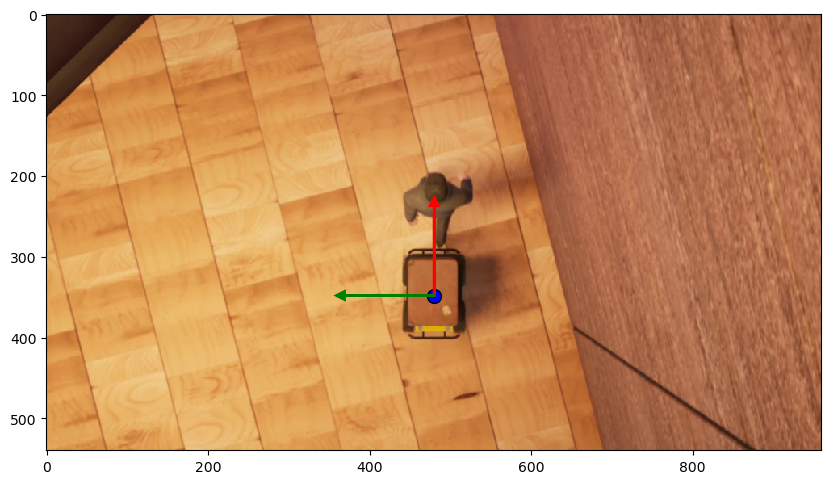

In [94]:
image = cv2.cvtColor(synced_frames[plot_idx], cv2.COLOR_BGR2RGB)
image_w, image_h = image.shape[1], image.shape[0]
print(f"Image size: {image_w}x{image_h}")
plt.figure(figsize=(10,10))
plt.imshow(image)
# plt.axis('off')

scale = 100/0.9  # 0.9m당 200 픽셀
T_image_robot = np.array([[0, -1,  0],
                          [1,  0, -0.7],
                          [0,  0, 1]]) # z축은 무시
# T_image_robot = np.eye(3)

R_image_robot = T_image_robot[:2,:2]
t_image_robot = T_image_robot[:2, 2]

def robot_to_image(pr: np.ndarray) -> np.ndarray:
    """2D world 좌표를 이미지 2D 좌표로 변환"""
    # pi = (R_image_robot.T @ (pw - t_image_robot).reshape(2,1)).reshape(2,)
    pi = (T_image_robot @ np.vstack((pr.reshape(2,1), 1)))
    # 이미지 좌표계: (0,0) 상단 좌측, x 우측, y 하단
    u = image_w/2 + pi[0] * scale
    v = image_h/2 - pi[1] * scale
    return np.array([u,v], dtype=float).squeeze()
origin = robot_to_image(np.array([0,0]))  # [960, 540]
x_arrow = robot_to_image(np.array([1,0]))  # [970, 540]
y_arrow = robot_to_image(np.array([0,1]))  # [960, 530]

plt.arrow(origin[0], origin[1], x_arrow[0]-origin[0], x_arrow[1]-origin[1],
          head_width=10, head_length=10, fc='r', ec='r', linewidth=2.0, zorder=100)
plt.arrow(origin[0], origin[1], y_arrow[0]-origin[0], y_arrow[1]-origin[1],
          head_width=10, head_length=10, fc='g', ec='g', linewidth=2.0, zorder=100)
plt.scatter([origin[0]], [origin[1]], s=100, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')


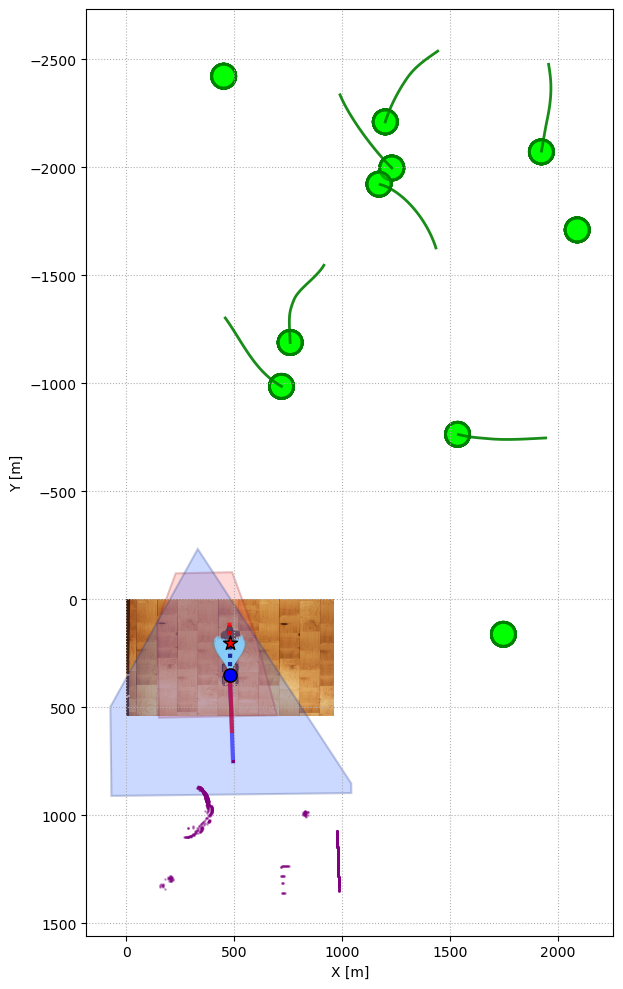

In [109]:
# plot on image

fig = plt.figure(figsize=(10,10))
ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
ax.imshow(image)
# ax.set_title(f"Snapshot + last {PATH_WINDOW_SEC:.1f}s paths at t={t_query:.2f}s ({TARGET_FRAME})")
plot_idx = 100
# yaw = robot_path_yaw[plot_idx] - np.pi/2  # x축이 로봇 진행 방향이 되도록 90도 회전
yaw = robot_path_yaw[plot_idx]
R_robot = np.array([[np.cos(-yaw), -np.sin(-yaw)],
                    [np.sin(-yaw),  np.cos(-yaw)]])
t_robot = -R_robot @ robot_path_xy[plot_idx]
T_robot = np.hstack([R_robot, t_robot.reshape(2,1)])  # (2,3)
T_robot = np.vstack([T_robot, [0,0,1]])  # (3,3)


def to_image_coords(pts: np.ndarray) -> np.ndarray:
    """2D pts (N,2)를 이미지 좌표로 변환"""
    pts_h = np.hstack([pts, np.ones((len(pts),1))])  # (N,3)
    pr = (T_robot @ pts_h.T).T  # (N,3)
    pts_img = (T_image_robot @ pr.T).T  # (N,3)

    pts_img = pts_img[:,:2] / pts_img[:,2:3]  # (N,2)
    pts_img[:,1] = -pts_img[:,1]  # y축 반전
    pts_img[:,0] = image_w/2 + pts_img[:,0] * scale
    pts_img[:,1] = image_h/2 + pts_img[:,1] * scale
    return pts_img


# raw (얇은 회색)
for seg in raw_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        P = to_image_coords(seg)
        ax.plot(P[:,0], P[:,1], linewidth=0.6, alpha=0.4, color='#808080' , zorder=10)  
# feasible (얇은 하늘색)
for seg in feas_segs_xy[plot_idx] or []:
    if seg is not None and len(seg) > 0:
        P = to_image_coords(seg)
        ax.plot(P[:,0], P[:,1], linewidth=0.8, alpha=0.5, color='#87CEFA', zorder=12)
# best (진한 파랑)
seg = best_segs_xy[plot_idx]
P = to_image_coords(seg)
ax.plot(P[:,0], P[:,1], linewidth=3.0, alpha=0.8, color='navy', linestyle=(0,(1.0,1.0)), zorder=14, label="Best trajectory")
# target best (진한 빨강)
seg = target_best_segs_xy[plot_idx]
P = to_image_coords(seg)
ax.plot(P[:,0], P[:,1], linewidth=3.0, alpha=0.8, color='red', linestyle=(0,(1.0,1.0)), zorder=14, label="Target best trajectory")
# corridors (면 제약 반영된 정확한 폴리곤)
def draw_polys(ax, polys, label=None, face=None, edge='k', alpha=0.25):
    used = False
    # for poly in polys:
    poly = np.asarray(polys)
    if poly.ndim != 2 or poly.shape[1] != 2 or len(poly) < 3:
        return
    P = to_image_coords(poly)
    xs = list(P[:,0]) + [P[0,0]]
    ys = list(P[:,1]) + [P[0,1]]
    ax.fill(xs, ys, facecolor=face, edgecolor=edge, alpha=alpha,
            linewidth=1.5, label=(label if not used else None))
    used = True
draw_polys(ax, corridorT_polys[plot_idx], label="Target corridor",
           face=(1.0, 0.4, 0.4), edge=(0.6, 0.1, 0.1), alpha=0.25)
draw_polys(ax, corridorR_polys[plot_idx], label="Robot corridor",
           face=(0.2, 0.4, 1.0), edge=(0.1, 0.2, 0.5), alpha=0.25)
# 동적 장애물
for i in range(10):
    pts = np.asarray(dyn_paths_xy_arr[:plot_idx,i], dtype=float)
    if pts.size > 0:
        P = to_image_coords(pts)
        ax.plot(P[:,0], P[:,1], color='green', linewidth=2.0, alpha=0.9, label=('Dyn path' if i==0 else None))
    for x, y in dyn_paths_xy_arr[plot_idx]:
        # p = R_robot @ np.array([x,y]) + t_robot
        p = np.array([x,y])
        p_img = to_image_coords(p.reshape(1,2)).reshape(2,)
        ax.add_patch(Circle((p_img[0], p_img[1]), CYL_RADIUS * scale, facecolor=(0.0,1.0,0.0,0.35), edgecolor='green', linewidth=2.0))
# 로봇/타겟 경로 + 현재 위치
P = np.asarray(robot_path_xy[:plot_idx], dtype=float)
# P = (R_robot @ P.T).T + t_robot
P_img = to_image_coords(P)
ax.plot(P_img[:,0], P_img[:,1], color='blue', linewidth=3.0, alpha=0.6, label='Robot path')
P = np.asarray(target_path_xy[:plot_idx], dtype=float)
# P = (R_robot @ P.T).T + t_robot
P_img = to_image_coords(P)
ax.plot(P_img[:,0], P_img[:,1], color='red', linewidth=3.0, alpha=0.6, label='Target path')
ax.scatter([origin[0]],[origin[1]], s=90, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')
# p_tgt = R_robot @ target_path_xy[plot_idx] + t_robot
p_tgt = target_path_xy[plot_idx]
p_tgt_img = to_image_coords(p_tgt.reshape(1,2)).reshape(2,)
ax.scatter([p_tgt_img[0]],[p_tgt_img[1]], s=110, marker='*', color='red', edgecolors='k', zorder=100, label='Target')
# LiDAR 포인트 클라우드
P = pcl_data[plot_idx]
if P is not None and P.shape[0] > 0:
    # P[:,:2] = (R_robot @ P[:,:2].T).T + t_robot
    P_img = to_image_coords(P[:,:2])
    ax.scatter(P_img[:,0], P_img[:,1], s=1.0, color='purple', alpha=0.3, label='Lidar points', zorder=5)

# P = pcl_data[plot_idx]
# if P is not None and P.shape[0] > 0:
#     P[:,:2] = (R_robot @ P[:,:2].T).T + t_robot
#     ax.scatter(P[:,0], P[:,1], s=1.0, color='purple', alpha=0.3, label='Lidar points', zorder=5)
    
ax.grid(True, linestyle=':')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.tight_layout(); plt.show()  

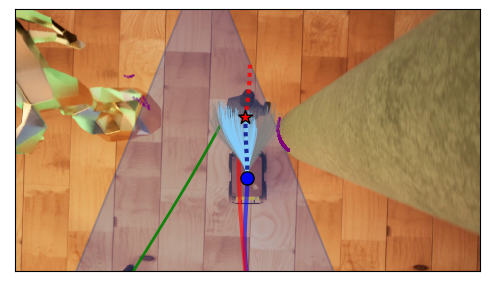

In [147]:
# plot on image


scale = 100/0.9  # 0.9m당 200 픽셀
T_image_robot = np.array([[0, -1,  0],
                          [1,  0, -0.7],
                          [0,  0, 1]]) # z축은 무시
image = cv2.cvtColor(synced_frames[0], cv2.COLOR_BGR2RGB)
image_w, image_h = image.shape[1], image.shape[0]

def to_image_coords(pts: np.ndarray, T_robot: np.ndarray) -> np.ndarray:
    """2D pts (N,2)를 이미지 좌표로 변환"""
    pts_h = np.hstack([pts, np.ones((len(pts),1))])  # (N,3)
    pr = (T_robot @ pts_h.T).T  # (N,3)
    pts_img = (T_image_robot @ pr.T).T  # (N,3)

    pts_img = pts_img[:,:2] / pts_img[:,2:3]  # (N,2)
    pts_img[:,1] = -pts_img[:,1]  # y축 반전
    pts_img[:,0] = image_w/2 + pts_img[:,0] * scale
    pts_img[:,1] = image_h/2 + pts_img[:,1] * scale
    return pts_img

def plot_on_image(plot_idx):
    image = cv2.cvtColor(synced_frames[plot_idx], cv2.COLOR_BGR2RGB)

    ax = plt.gca(); ax.set_aspect('equal', adjustable='box')
    ax.imshow(image)
    # ax.set_title(f"Snapshot + last {PATH_WINDOW_SEC:.1f}s paths at t={t_query:.2f}s ({TARGET_FRAME})")

    # yaw = robot_path_yaw[plot_idx] - np.pi/2  # x축이 로봇 진행 방향이 되도록 90도 회전
    yaw = robot_path_yaw[plot_idx]
    R_robot = np.array([[np.cos(-yaw), -np.sin(-yaw)],
                        [np.sin(-yaw),  np.cos(-yaw)]])
    t_robot = -R_robot @ robot_path_xy[plot_idx]
    T_robot = np.hstack([R_robot, t_robot.reshape(2,1)])  # (2,3)
    T_robot = np.vstack([T_robot, [0,0,1]])  # (3,3)

    # raw (얇은 회색)
    for seg in raw_segs_xy[plot_idx] or []:
        if seg is not None and len(seg) > 0:
            P = to_image_coords(seg, T_robot)
            ax.plot(P[:,0], P[:,1], linewidth=0.6, alpha=0.4, color='#808080' , zorder=10)  
    # feasible (얇은 하늘색)
    for seg in feas_segs_xy[plot_idx] or []:
        if seg is not None and len(seg) > 0:
            P = to_image_coords(seg, T_robot)
            ax.plot(P[:,0], P[:,1], linewidth=0.8, alpha=0.5, color='#87CEFA', zorder=12)
    # best (진한 파랑)
    seg = best_segs_xy[plot_idx]
    P = to_image_coords(seg, T_robot)
    ax.plot(P[:,0], P[:,1], linewidth=3.0, alpha=0.8, color='navy', linestyle=(0,(1.0,1.0)), zorder=14, label="Best trajectory")
    # target best (진한 빨강)
    seg = target_best_segs_xy[plot_idx]
    P = to_image_coords(seg, T_robot)
    ax.plot(P[:,0], P[:,1], linewidth=3.0, alpha=0.8, color='red', linestyle=(0,(1.0,1.0)), zorder=14, label="Target best trajectory")
    # corridors (면 제약 반영된 정확한 폴리곤)
    def draw_polys(ax, polys, label=None, face=None, edge='k', alpha=0.25):
        used = False
        # for poly in polys:
        poly = np.asarray(polys)
        if poly.ndim != 2 or poly.shape[1] != 2 or len(poly) < 3:
            return
        P = to_image_coords(poly, T_robot)
        xs = list(P[:,0]) + [P[0,0]]
        ys = list(P[:,1]) + [P[0,1]]
        ax.fill(xs, ys, facecolor=face, edgecolor=edge, alpha=alpha,
                linewidth=1.5, label=(label if not used else None))
        used = True
    # draw_polys(ax, corridorT_polys[plot_idx], label="Target corridor",
    #         face=(1.0, 0.4, 0.4), edge=(0.6, 0.1, 0.1), alpha=0.25)
    draw_polys(ax, corridorR_polys[plot_idx], label="Robot corridor",
            face=(0.2, 0.4, 1.0), edge=(0.1, 0.2, 0.5), alpha=0.25)
    # 동적 장애물
    for i in range(10):
        pts = np.asarray(dyn_paths_xy_arr[plot_idx-100:plot_idx,i], dtype=float)
        if pts.size > 0:
            P = to_image_coords(pts, T_robot)
            ax.plot(P[:,0], P[:,1], color='green', linewidth=2.0, alpha=0.9, label=('Dyn path' if i==0 else None))
        for x, y in dyn_paths_xy_arr[plot_idx]:
            # p = R_robot @ np.array([x,y]) + t_robot
            p = np.array([x,y])
            p_img = to_image_coords(p.reshape(1,2), T_robot).reshape(2,)
            ax.add_patch(Circle((p_img[0], p_img[1]), CYL_RADIUS * scale / 5, facecolor=(0.0,1.0,0.0,0.35), edgecolor='green', linewidth=2.0))
    # 로봇/타겟 경로 + 현재 위치
    P = np.asarray(robot_path_xy[:plot_idx], dtype=float)
    # P = (R_robot @ P.T).T + t_robot
    P_img = to_image_coords(P, T_robot)
    ax.plot(P_img[:,0], P_img[:,1], color='blue', linewidth=3.0, alpha=0.6, label='Robot path')
    P = np.asarray(target_path_xy[:plot_idx], dtype=float)
    # P = (R_robot @ P.T).T + t_robot
    P_img = to_image_coords(P, T_robot)
    ax.plot(P_img[:,0], P_img[:,1], color='red', linewidth=3.0, alpha=0.6, label='Target path')
    ax.scatter([origin[0]],[origin[1]], s=90, marker='o', color='blue', edgecolors='k', zorder=100, label='Robot')
    # p_tgt = R_robot @ target_path_xy[plot_idx] + t_robot
    p_tgt = target_path_xy[plot_idx]
    p_tgt_img = to_image_coords(p_tgt.reshape(1,2), T_robot).reshape(2,)
    ax.scatter([p_tgt_img[0]],[p_tgt_img[1]], s=110, marker='*', color='red', edgecolors='k', zorder=100, label='Target')

    # LiDAR 포인트 클라우드
    P = pcl_data[plot_idx]
    if P is not None and P.shape[0] > 0:
        # P[:,:2] = (R_robot @ P[:,:2].T).T + t_robot
        P_img = to_image_coords(P[:,:2], T_robot)
        ax.scatter(P_img[:,0], P_img[:,1], s=1.0, color='purple', alpha=0.3, label='Lidar points', zorder=5)
    ax.grid(True, linestyle=':')
    # plt.xlabel('X [m]'); plt.ylabel('Y [m]')
    plt.xlim(0, image_w); plt.ylim(image_h, 0)
    # 여백 없이 plot
    plt.tight_layout()
    

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
# off ticks
ax.set_xticks([])
ax.set_yticks([])
index = 1650
plot_on_image(index)
plt.savefig("snapshot_on_{}.pdf".format(index), bbox_inches='tight', pad_inches=0)
plt.show()


INFO - 2025-10-02 12:46:59,163 - animation - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO - 2025-10-02 12:46:59,163 - animation - figure size (inches) has been adjusted from 7.111111111111111 x 4.0 to 7.11 x 4.0
INFO - 2025-10-02 12:46:59,163 - animation - MovieWriter.run: running command: ['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1422x800', '-pix_fmt', 'rgba', '-r', '31.473354912280673', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'top_down_with_plot.mp4']


Saving video to top_down_with_plot.mp4 at 31.47 FPS
Video saved to top_down_with_plot.mp4


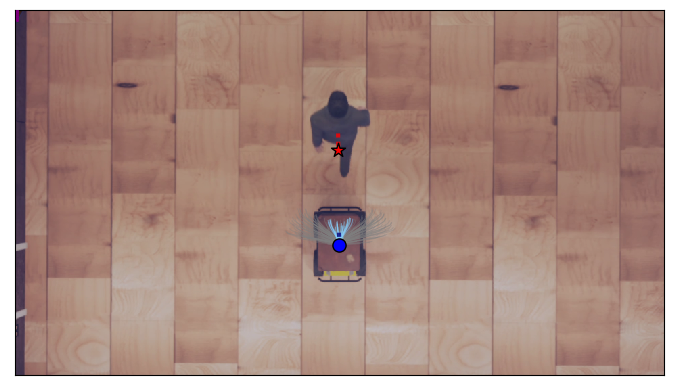

In [143]:
# save as mp4

mp4_path = "top_down_with_plot.mp4"

# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# fps = robot_t.shape[0] / (robot_t[-1] - robot_t[0])
# print(f"Saving video to {mp4_path} at {fps:.2f} FPS")
# out = cv2.VideoWriter(mp4_path, fourcc, 30.0, (image_w, image_h))

# for i in tqdm(range(100), desc="Creating video", ncols=100, unit="frame"):
#     fig = plt.figure(figsize=(10,10))
#     ax = plt.gca()
#     # off ticks
#     ax.set_xticks([])
#     ax.set_yticks([])
#     plot_on_image(i)
#     plt.tight_layout()

#     # Convert Matplotlib figure to a numpy array
#     fig.canvas.draw()
#     img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
#     img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
#     plt.close(fig)

#     # Convert RGB to BGR for OpenCV
#     img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
#     out.write(img_bgr)

# out.release()
# print(f"Video saved to {mp4_path}")

import matplotlib.animation as animation
w_h_ratio = image_w / image_h

fig = plt.figure(figsize=(w_h_ratio * 4, 4))
ax = plt.gca()
# off ticks
ax.set_xticks([])
ax.set_yticks([])

def update(frame):
    ax.clear()
    # off ticks
    ax.set_xticks([])
    ax.set_yticks([])
    plot_on_image(frame)
    # plt.tight_layout()

fps = robot_t.shape[0] / (robot_t[-1] - robot_t[0])
print(f"Saving video to {mp4_path} at {fps:.2f} FPS")
ani = animation.FuncAnimation(fig, update, frames=len(robot_t), interval=1000/fps)
ani.save(mp4_path, writer='ffmpeg', dpi=200)
print(f"Video saved to {mp4_path}")
# plt.show()

# 정사영시키기?

In [ ]:

from open3d.visualization.rendering import Material

center = mesh.get_center()
bbox = mesh.get_axis_aligned_bounding_box()
extent = bbox.get_extent()
half_w, half_h = extent[0]/2, extent[1]/2
near, far = 0.1, extent[2] + 10.0

app = o3d.visualization.gui.Application.instance
app.initialize()

w = o3d.visualization.gui.Application.instance.create_window("Ortho Top-Down", 1280, 800)
scene_widget = o3d.visualization.gui.SceneWidget()
scene_widget.scene = o3d.visualization.rendering.Open3DScene(w.renderer)
scene_widget.scene.add_geometry("mesh", mesh, o3d.visualization.rendering.Material())

w.add_child(scene_widget)

# 카메라 위치/방향: z+ 위에서 아래로
cam = scene_widget.scene.camera

eye = center + np.array([0, 0, extent[2]*2.0])   # 위쪽(z+)에서 내려다봄
look = center
up   = [0, 1, 0]
cam.look_at(look, eye, up)


# 정사영 설정 (Projection enum, left, right, bottom, top, near, far)
cam.set_projection(o3d.visualization.rendering.Camera.Projection.Ortho,  # Ortho projection
                   -half_w, half_w,    # left, right
                   -half_h, half_h,    # bottom, top  
                   near, far)          # near, far

# 배경/조명 등 옵션(선택)
scene_widget.scene.show_axes(True)

app.run()

[Open3D INFO] Window window_0 created.
[Open3D INFO] EGL headless mode enabled.
[Open3D INFO] ICE servers: {"stun:stun.l.google.com:19302", "turn:user:password@34.69.27.100:3478", "turn:user:password@34.69.27.100:3478?transport=tcp"}
FEngine (64 bits) created at 0x1c04d860 (threading is enabled)
[Open3D INFO] Set WEBRTC_STUN_SERVER environment variable add a customized WebRTC STUN server.
EGL(1.5)
OpenGL(4.1)
[Open3D INFO] WebRTC Jupyter handshake mode enabled.


TypeError: set_projection(): incompatible function arguments. The following argument types are supported:
    1. (self: open3d.cpu.pybind.visualization.rendering.Camera, arg0: float, arg1: float, arg2: float, arg3: float, arg4: open3d.cpu.pybind.visualization.rendering.Camera.FovType) -> None
    2. (self: open3d.cpu.pybind.visualization.rendering.Camera, arg0: open3d.cpu.pybind.visualization.rendering.Camera.Projection, arg1: float, arg2: float, arg3: float, arg4: float, arg5: float, arg6: float) -> None
    3. (self: open3d.cpu.pybind.visualization.rendering.Camera, arg0: numpy.ndarray[float64[3, 3]], arg1: float, arg2: float, arg3: float, arg4: float) -> None

Invoked with: <open3d.cpu.pybind.visualization.rendering.Camera object at 0x7fc270430a70>, True, -1127.4995727539062, 1127.4995727539062, -895.3302612304688, 895.3302612304688, 0.1, 295.2213134765625

735.0